In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
df = pd.read_csv("./dataset/Restaurant.csv")
df.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,VIOLATION CODE,VIOLATION DESCRIPTION,CRITICAL FLAG,SCORE,GRADE,GRADE DATE,RECORD DATE,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50163224,BAKED CHEESE HAUS LTD,Manhattan,1,HERALD SQUARE,10001.0,6086301355,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.750542,-73.987541,105.0,4.0,10900.0,1089436.0,1.008100e+09,MN17,POINT (-73.987541021756 40.750541907818)
1,50170678,D'S GRAB N GO,Brooklyn,74,RICHARDSON STREET,11211.0,6463025617,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.718374,-73.949138,301.0,34.0,51500.0,3068058.0,3.027320e+09,BK73,POINT (-73.94913846043 40.718373646442)
2,50171263,NAYA ROCK CENTER LLC,Manhattan,30,ROCKEFELLER PLAZA,10112.0,2124612812,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.758747,-73.978692,105.0,4.0,10400.0,1076262.0,1.012658e+09,MN17,POINT (-73.978692223615 40.758747437799)
3,50172771,AZ&G INC,Queens,133-33,39 AVENUE,11354.0,7188198818,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.759110,-73.834161,407.0,20.0,87100.0,4000000.0,4.049728e+09,QN22,POINT (-73.834160749112 40.759109919719)
4,50165402,AREFIN'S TEA MANIA NEW YORK,Queens,98-04,101 AVENUE,11416.0,3478844480,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,03/03/2026,NaN,40.685049,-73.843194,409.0,32.0,4001.0,4439922.0,4.091050e+09,QN53,POINT (-73.843193921 40.685049473493)


In [5]:
df.describe()

,CAMIS,ZIPCODE,SCORE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL
count,2.967660e+05,293576.000000,280188.000000,295339.000000,295339.000000,292176.000000,292203.000000,292203.000000,2.909300e+05,2.953390e+05
mean,4.806145e+07,10706.923161,25.161749,40.292099,-73.148456,254.923769,20.568711,29882.587995,2.586012e+06,2.478446e+09
std,3.755423e+06,616.227171,18.731612,4.192801,7.611227,130.374503,15.668773,31292.127581,1.356210e+06,1.338448e+09
min,3.007544e+07,6605.000000,0.000000,0.000000,-74.249101,101.000000,1.000000,100.000000,1.000000e+06,1.000000e+00
25%,5.000430e+07,10023.000000,12.000000,40.686661,-73.988620,106.000000,4.000000,8000.000000,1.051461e+06,1.011110e+09
50%,5.009207e+07,11101.000000,21.000000,40.732855,-73.955697,302.000000,20.000000,17300.000000,3.021633e+06,3.008020e+09
75%,5.012999e+07,11232.000000,33.000000,40.761237,-73.893827,402.000000,34.000000,42600.000000,4.011502e+06,4.006290e+09
max,5.018247e+07,69361.000000,203.000000,40.912822,0.000000,595.000000,51.000000,162100.000000,5.799501e+06,5.270001e+09


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296766 entries, 0 to 296765
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  296766 non-null  int64  
 1   DBA                    296764 non-null  object 
 2   BORO                   296766 non-null  object 
 3   BUILDING               295807 non-null  object 
 4   STREET                 296765 non-null  object 
 5   ZIPCODE                293576 non-null  float64
 6   PHONE                  296752 non-null  object 
 7   CUISINE DESCRIPTION    293485 non-null  object 
 8   INSPECTION DATE        296766 non-null  object 
 9   ACTION                 293485 non-null  object 
 10  VIOLATION CODE         291191 non-null  object 
 11  VIOLATION DESCRIPTION  291190 non-null  object 
 12  CRITICAL FLAG          296766 non-null  object 
 13  SCORE                  280188 non-null  float64
 14  GRADE                  146385 non-nu

# Early Preprocessing

## Ubah ke Inspection Level ##

In [8]:
for col in ["INSPECTION DATE", "GRADE DATE", "RECORD DATE"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

record_date = df["RECORD DATE"].dropna().max()
start_date = record_date - pd.DateOffset(years=3)

df_recent = df[
    (df["INSPECTION DATE"].notna()) &
    (df["INSPECTION DATE"] >= start_date) &
    (df["INSPECTION DATE"] <= record_date)
].copy()

df_recent["SCORE"] = pd.to_numeric(df_recent["SCORE"], errors="coerce")
df_recent["BORO"] = df_recent["BORO"].replace("0", "Unknown")
df_recent["VIOLATION CODE"] = df_recent["VIOLATION CODE"].astype("string").str.strip()
df_recent["CRITICAL FLAG"] = df_recent["CRITICAL FLAG"].astype("string").str.strip().str.lower()

inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

df_ins = (
    df_recent.groupby(inspection_key, as_index=False, dropna=False)
    .agg(
        DBA=("DBA", "first"),
        BORO=("BORO", "first"),
        BUILDING=("BUILDING", "first"),
        STREET=("STREET", "first"),
        ZIPCODE=("ZIPCODE", "first"),
        PHONE=("PHONE", "first"),
        CUISINE_DESCRIPTION=("CUISINE DESCRIPTION", "first"),
        ACTION=("ACTION", "first"),
        SCORE=("SCORE", "first"),
        GRADE=("GRADE", "first"),
        GRADE_DATE=("GRADE DATE", "first"),
        Latitude=("Latitude", "first"),
        Longitude=("Longitude", "first"),
        Community_Board=("Community Board", "first"),
        Council_District=("Council District", "first"),
        Census_Tract=("Census Tract", "first"),
        BIN=("BIN", "first"),
        BBL=("BBL", "first"),
        NTA=("NTA", "first"),
        violation_count=("VIOLATION CODE", lambda x: x.dropna().ne("").sum()),
        critical_count=("CRITICAL FLAG", lambda x: (x == "critical").sum()),
        has_critical=("CRITICAL FLAG", lambda x: (x == "critical").any())
    )
)

df_ins.head()

,CAMIS,INSPECTION DATE,INSPECTION TYPE,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE_DESCRIPTION,ACTION,SCORE,GRADE,GRADE_DATE,Latitude,Longitude,Community_Board,Council_District,Census_Tract,BIN,BBL,NTA,violation_count,critical_count,has_critical
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,38.0,None,NaT,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,2,True
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,12.0,A,2023-08-22,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,10.0,A,2024-11-08,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,3,1,True
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,MORRIS PARK BAKE SHOP,Bronx,1007,MORRIS PARK AVENUE,10462.0,7188924968,Bakery Products/Desserts,Violations were cited in the following area(s).,7.0,A,2026-02-27,40.848231,-73.855972,211.0,13.0,25200.0,2045445.0,2.041270e+09,BX37,2,1,True
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,D.J. REYNOLDS,Manhattan,351,WEST 57 STREET,10019.0,2122452912,Irish,Violations were cited in the following area(s).,10.0,A,2023-04-23,40.767326,-73.984310,104.0,3.0,13900.0,1026048.0,1.010480e+09,MN15,2,2,True


In [ ]:
df_ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77629 entries, 0 to 77628
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CAMIS                77629 non-null  int64         
 1   INSPECTION DATE      77629 non-null  datetime64[ns]
 2   INSPECTION TYPE      77629 non-null  object        
 3   DBA                  77629 non-null  object        
 4   BORO                 77629 non-null  object        
 5   BUILDING             77390 non-null  object        
 6   STREET               77629 non-null  object        
 7   ZIPCODE              76772 non-null  float64       
 8   PHONE                77626 non-null  object        
 9   CUISINE_DESCRIPTION  77629 non-null  object        
 10  ACTION               77629 non-null  object        
 11  SCORE                68860 non-null  float64       
 12  GRADE                46347 non-null  object        
 13  GRADE_DATE           44221 non-

In [ ]:
df_ins.duplicated().sum()

np.int64(0)

In [ ]:
df_ins.isna().sum()

CAMIS                      0
INSPECTION DATE            0
INSPECTION TYPE            0
DBA                        0
BORO                       0
BUILDING                 239
STREET                     0
ZIPCODE                  857
PHONE                      3
CUISINE_DESCRIPTION        0
ACTION                     0
SCORE                   8769
GRADE                  31282
GRADE_DATE             33408
Latitude                 386
Longitude                386
Community_Board         1234
Council_District        1230
Census_Tract            1230
BIN                     1604
BBL                      386
NTA                     1234
violation_count            0
critical_count             0
has_critical               0
dtype: int64

**Drop Missing Value in Score**

In [ ]:
df_ins = df_ins.dropna(subset=["SCORE"]).copy()
df_ins['SCORE'].isna().sum()

np.int64(0)

**Penjelasan:** Drop baris yang SCORE-nya null karena SCORE adalah kolom target, tidak bisa diimputasi

In [ ]:
df_ins.columns

Index(['CAMIS', 'INSPECTION DATE', 'INSPECTION TYPE', 'DBA', 'BORO',
       'BUILDING', 'STREET', 'ZIPCODE', 'PHONE', 'CUISINE_DESCRIPTION',
       'ACTION', 'SCORE', 'GRADE', 'GRADE_DATE', 'Latitude', 'Longitude',
       'Community_Board', 'Council_District', 'Census_Tract', 'BIN', 'BBL',
       'NTA', 'violation_count', 'critical_count', 'has_critical'],
      dtype='object')

## Ubah Tipe Data ##

In [ ]:
for col in ["INSPECTION DATE", "GRADE_DATE"]:
    df_ins[col] = pd.to_datetime(df_ins[col], errors="coerce")

for col in ["SCORE", "Latitude", "Longitude"]:
    df_ins[col] = pd.to_numeric(df_ins[col], errors="coerce")

df_ins["ZIPCODE"] = df_ins["ZIPCODE"].astype("string").astype("category")

for col in ["BORO", "CUISINE_DESCRIPTION", "INSPECTION TYPE"]:
    df_ins[col] = df_ins[col].astype("category")
    
df_ins.dtypes

CAMIS                           int64
INSPECTION DATE        datetime64[ns]
INSPECTION TYPE              category
DBA                            object
BORO                         category
BUILDING                       object
STREET                         object
ZIPCODE                      category
PHONE                          object
CUISINE_DESCRIPTION          category
ACTION                         object
SCORE                         float64
GRADE                          object
GRADE_DATE             datetime64[ns]
Latitude                      float64
Longitude                     float64
Community_Board               float64
Council_District              float64
Census_Tract                  float64
BIN                           float64
BBL                           float64
NTA                            object
violation_count                 int64
critical_count                  int64
has_critical                     bool
dtype: object

**Penjelasan:** Yang Date itu krn tanggal jd pake datetime, yg score, latitude dan longitude itu bakal diproses secara numerik, selainnya itu krn emang kategorikal jadi diubah ke category aja

## Fitur inti ##

In [ ]:
df_ins["inspection_year"] = df_ins["INSPECTION DATE"].dt.year
df_ins["inspection_month"] = df_ins["INSPECTION DATE"].dt.month
df_ins["inspection_quarter"] = df_ins["INSPECTION DATE"].dt.quarter
df_ins["inspection_dayofweek"] = df_ins["INSPECTION DATE"].dt.dayofweek

base_features = [
    "CUISINE_DESCRIPTION",
    "BORO",
    "ZIPCODE",
    "Latitude",
    "Longitude",
    "Community_Board",
    "INSPECTION TYPE",
    "inspection_year",
    "inspection_month",
    "inspection_quarter",
    "inspection_dayofweek"
]

df_base = df_ins[
    ["CAMIS", "INSPECTION DATE", "SCORE"] + base_features
].copy()

df_base.head()

,CAMIS,INSPECTION DATE,SCORE,CUISINE_DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,Community_Board,INSPECTION TYPE,inspection_year,inspection_month,inspection_quarter,inspection_dayofweek
0,30075445,2023-08-01,38.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2023,8,3,1
1,30075445,2023-08-22,12.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Re-inspection,2023,8,3,1
2,30075445,2024-11-08,10.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2024,11,4,4
3,30075445,2026-02-27,7.0,Bakery Products/Desserts,Bronx,10462.0,40.848231,-73.855972,211.0,Cycle Inspection / Initial Inspection,2026,2,1,4
4,30191841,2023-04-23,10.0,Irish,Manhattan,10019.0,40.767326,-73.984310,104.0,Cycle Inspection / Initial Inspection,2023,4,2,6


In [ ]:
df_base.columns

Index(['CAMIS', 'INSPECTION DATE', 'SCORE', 'CUISINE_DESCRIPTION', 'BORO',
       'ZIPCODE', 'Latitude', 'Longitude', 'Community_Board',
       'INSPECTION TYPE', 'inspection_year', 'inspection_month',
       'inspection_quarter', 'inspection_dayofweek'],
      dtype='object')

In [ ]:
df_base.dtypes

CAMIS                            int64
INSPECTION DATE         datetime64[ns]
SCORE                          float64
CUISINE_DESCRIPTION           category
BORO                          category
ZIPCODE                       category
Latitude                       float64
Longitude                      float64
Community_Board                float64
INSPECTION TYPE               category
inspection_year                  int32
inspection_month                 int32
inspection_quarter               int32
inspection_dayofweek             int32
dtype: object

## Handle Missing Value Boro, Zipcode, Cuisine Description, Inspection Type ##

In [ ]:
cat_cols = ["BORO", "ZIPCODE", "CUISINE_DESCRIPTION", "INSPECTION TYPE"]

for col in cat_cols:
    df_base[col] = df_base[col].replace(r"^\s*$", pd.NA, regex=True)

    if str(df_base[col].dtype) == "category":
        if "Unknown" not in df_base[col].cat.categories:
            df_base[col] = df_base[col].cat.add_categories(["Unknown"])

    df_base[col] = df_base[col].fillna("Unknown")
    
df_base[cat_cols].isna().sum()

BORO                   0
ZIPCODE                0
CUISINE_DESCRIPTION    0
INSPECTION TYPE        0
dtype: int64

In [ ]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 68860 entries, 0 to 77627
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CAMIS                 68860 non-null  int64         
 1   INSPECTION DATE       68860 non-null  datetime64[ns]
 2   SCORE                 68860 non-null  float64       
 3   CUISINE_DESCRIPTION   68860 non-null  category      
 4   BORO                  68860 non-null  category      
 5   ZIPCODE               68860 non-null  category      
 6   Latitude              68505 non-null  float64       
 7   Longitude             68505 non-null  float64       
 8   Community_Board       67732 non-null  float64       
 9   INSPECTION TYPE       68860 non-null  category      
 10  inspection_year       68860 non-null  int32         
 11  inspection_month      68860 non-null  int32         
 12  inspection_quarter    68860 non-null  int32         
 13  inspection_dayofweek 

## Handle Missing Value Community Board ##

In [ ]:
df_base["Community_Board"] = df_base["Community_Board"].astype(str)
df_base["Community_Board"] = df_base["Community_Board"].replace(r"^\s*$", pd.NA, regex=True)
df_base["Community_Board"] = df_base["Community_Board"].fillna("Unknown")
df_base[["Community_Board"]].isna().sum()

Community_Board    0
dtype: int64

## Handle Missing Value Latitude Longitude ##

In [ ]:
df_base[['Latitude', 'Longitude']].isna().sum()

Latitude     355
Longitude    355
dtype: int64

In [ ]:
df_base["Latitude"] = pd.to_numeric(df_base["Latitude"], errors="coerce")
df_base["Longitude"] = pd.to_numeric(df_base["Longitude"], errors="coerce")

df_base.loc[df_base["Latitude"] == 0, "Latitude"] = pd.NA
df_base.loc[df_base["Longitude"] == 0, "Longitude"] = pd.NA

df_base["Latitude"] = df_base["Latitude"].fillna(
    df_base.groupby("CAMIS")["Latitude"].transform("median")
)

df_base["Longitude"] = df_base["Longitude"].fillna(
    df_base.groupby("CAMIS")["Longitude"].transform("median")
)

df_base["Latitude"] = df_base["Latitude"].fillna(df_base["Latitude"].median())
df_base["Longitude"] = df_base["Longitude"].fillna(df_base["Longitude"].median())

In [ ]:
df_base[['Latitude', 'Longitude']].isna().sum()

Latitude     0
Longitude    0
dtype: int64

In [ ]:
df_base.isna().sum()

CAMIS                   0
INSPECTION DATE         0
SCORE                   0
CUISINE_DESCRIPTION     0
BORO                    0
ZIPCODE                 0
Latitude                0
Longitude               0
Community_Board         0
INSPECTION TYPE         0
inspection_year         0
inspection_month        0
inspection_quarter      0
inspection_dayofweek    0
dtype: int64

## Top Category Cuisine & Inspection Type ##

In [ ]:
TOP_N_CUISINE = 15
TOP_N_INSTYPE = 5

top_cuisine = df_base["CUISINE_DESCRIPTION"].value_counts().nlargest(TOP_N_CUISINE).index
df_base["CUISINE_DESCRIPTION"] = (
    df_base["CUISINE_DESCRIPTION"]
    .apply(lambda x: x if x in top_cuisine else "Other")
)

top_instype = df_base["INSPECTION TYPE"].value_counts().nlargest(TOP_N_INSTYPE).index
df_base["INSPECTION TYPE"] = (
    df_base["INSPECTION TYPE"]
    .apply(lambda x: x if x in top_instype else "Other")
)

In [ ]:
print(df_base["CUISINE_DESCRIPTION"].value_counts())
print()
print(df_base["INSPECTION TYPE"].value_counts())
print(df_base["CUISINE_DESCRIPTION"].nunique())
print(df_base["INSPECTION TYPE"].nunique())

CUISINE_DESCRIPTION
Other                             18539
American                          11072
Chinese                            6221
Coffee/Tea                         5862
Pizza                              4184
Latin American                     2900
Bakery Products/Desserts           2778
Mexican                            2708
Japanese                           2364
Caribbean                          2259
Italian                            2191
Chicken                            1914
Donuts                             1701
Juice, Smoothies, Fruit Salads     1418
Spanish                            1414
Hamburgers                         1335
Name: count, dtype: int64

INSPECTION TYPE
Cycle Inspection / Initial Inspection            38133
Cycle Inspection / Re-inspection                 14453
Pre-permit (Operational) / Initial Inspection     9378
Other                                             3067
Pre-permit (Operational) / Re-inspection          2774
Cycle Inspection / Reo

**Penjelasan:** Cuisine diambil yang top 15 agar tidak terlalu banyak kategori karena diluar top 15 jumlahnya juga dikit, inspection type diambil yang top 5 aja dengan alasan yang sama selebihnya dikelompokkan sebagai Other

# Advanced Preprocessing

## Step 1 - Advanced Preprocessing: Feature Engineering dari Violation ##

- `df_ins` sudah mengagregasi `violation_count`, `critical_count`, dan `has_critical`
- Namun fitur-fitur ini **tidak ikut masuk ke `df_base`** saat pemilihan kolom
- Langkah ini melengkapi fitur violation yang kurang, lalu menarik semuanya ke `df_base`


In [ ]:
inspection_key = ["CAMIS", "INSPECTION DATE", "INSPECTION TYPE"]

print("rows awal:", df_recent.shape[0])
print("unique inspeksi:",
      df_recent[inspection_key].drop_duplicates().shape[0])

viol_clean = df_recent.copy()
viol_clean['CRITICAL FLAG'] = viol_clean['CRITICAL FLAG'].str.strip().str.lower()
viol_clean['VIOLATION CODE'] = viol_clean['VIOLATION CODE'].str.strip()

viol_clean = viol_clean[
    viol_clean["VIOLATION CODE"].notna() &
    (viol_clean["VIOLATION CODE"] != "") &
    (viol_clean["VIOLATION CODE"].str.lower() != "nan")
].copy()

viol_clean = viol_clean.drop_duplicates(
    subset=['CAMIS', 'INSPECTION DATE', 'INSPECTION TYPE', 'VIOLATION CODE']
).copy()

viol_features = viol_clean.groupby(
    ['CAMIS', 'INSPECTION DATE','INSPECTION TYPE']
).agg(
    critical_count=("CRITICAL FLAG", lambda x: (x == "critical").sum()),
    has_critical=("CRITICAL FLAG", lambda x: (x == "critical").any()),
    noncritical_count=("CRITICAL FLAG", lambda x: (x != "critical").sum()),
    violation_count=('VIOLATION CODE', 'count'),
    unique_viol_codes=('VIOLATION CODE', 'nunique')
).reset_index()

viol_features['has_critical'] = (viol_features['critical_count'] > 0).astype(int)

viol_features['critical_ratio'] = (
    viol_features['critical_count'] / viol_features['violation_count']
).fillna(0)

print("Jumlah duplikat:", viol_features.duplicated().sum())
print("Shape:", viol_features.shape)
viol_features.head()

rows awal: 243361
unique inspeksi: 77629
Jumlah duplikat: 0
Shape: (75607, 9)


,CAMIS,INSPECTION DATE,INSPECTION TYPE,critical_count,has_critical,noncritical_count,violation_count,unique_viol_codes,critical_ratio
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,2,1,1,3,3,0.666667
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,1,1,2,3,3,0.333333
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,1,1,2,3,3,0.333333
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,1,1,1,2,2,0.500000
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,2,1,0,2,2,1.000000


**1b. Binary Flag untuk Top Violation Codes dengan score tertinggi**

Dari EDA diketahui 9/10 violation code dengan median score tertinggi adalah critical code (05F, 06C, dst).
Membuat flag kehadiran kode-kode tersebut sebagai fitur eksplisit.


In [ ]:
TOP_VIOL_CODES = ["10F", "08A", "06D", "10B", "02G", "06C", "02B", "04L", "04N", "04A", "05F", "04H", "05D", "06F"]

code_pivot = (
    viol_clean[viol_clean["VIOLATION CODE"].isin(TOP_VIOL_CODES)]
    .assign(val=1)
    .pivot_table(
        index=inspection_key,
        columns="VIOLATION CODE",
        values="val",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

code_pivot.columns.name = None
code_pivot = code_pivot.rename(
    columns={c: f"viol_{c}" for c in TOP_VIOL_CODES if c in code_pivot.columns}
)

print("Shape code_pivot:", code_pivot.shape)
code_pivot.head()

Shape code_pivot: (65337, 17)


,CAMIS,INSPECTION DATE,INSPECTION TYPE,viol_02B,viol_02G,viol_04A,viol_04H,viol_04L,viol_04N,viol_05D,viol_05F,viol_06C,viol_06D,viol_06F,viol_08A,viol_10B,viol_10F
0,30075445,2023-08-01,Cycle Inspection / Initial Inspection,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,30075445,2023-08-22,Cycle Inspection / Re-inspection,0,0,0,0,1,0,0,0,0,0,0,1,0,0
2,30075445,2024-11-08,Cycle Inspection / Initial Inspection,0,0,0,0,0,0,0,0,1,0,0,0,0,1
3,30075445,2026-02-27,Cycle Inspection / Initial Inspection,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,30191841,2023-04-23,Cycle Inspection / Initial Inspection,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [ ]:
for col in inspection_key:
    viol_features[col]  = viol_features[col].astype(str)
    code_pivot[col]     = code_pivot[col].astype(str)
    df_base[col]        = df_base[col].astype(str)

df_base = df_base.merge(viol_features, on=inspection_key, how="left")

df_base = df_base.merge(code_pivot, on=inspection_key, how="left")

viol_numeric_cols = (
    ["violation_count", "unique_viol_codes", "critical_count",
     "noncritical_count", "critical_ratio"]
    + [c for c in df_base.columns if c.startswith("viol_")]
)

df_base[viol_numeric_cols] = df_base[viol_numeric_cols].fillna(0)
df_base["has_critical"] = df_base["has_critical"].fillna(False)

print("Shape df_base setelah merge violation features:", df_base.shape)
print("\nKolom baru yang ditambahkan:")
print([c for c in df_base.columns if c in viol_numeric_cols or c == "has_critical"])

Shape df_base setelah merge violation features: (68860, 34)

Kolom baru yang ditambahkan:
['critical_count', 'has_critical', 'noncritical_count', 'violation_count', 'unique_viol_codes', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'viol_10B', 'viol_10F']


In [ ]:
print("=== Info df_base ===")
df_base[viol_numeric_cols + ["has_critical"]].describe()
print()
print("=== Missing values fitur violation ===")
print(df_base[viol_numeric_cols + ["has_critical"]].isna().sum())
print()
print("=== Contoh data ===")
df_base[[
    "CAMIS", "INSPECTION DATE", "SCORE",
    "violation_count", "critical_count", "noncritical_count",
    "unique_viol_codes", "critical_ratio", "has_critical"
]].head(10)

=== Info df_base ===

=== Missing values fitur violation ===
violation_count      0
unique_viol_codes    0
critical_count       0
noncritical_count    0
critical_ratio       0
viol_02B             0
viol_02G             0
viol_04A             0
viol_04H             0
viol_04L             0
viol_04N             0
viol_05D             0
viol_05F             0
viol_06C             0
viol_06D             0
viol_06F             0
viol_08A             0
viol_10B             0
viol_10F             0
has_critical         0
dtype: int64

=== Contoh data ===


,CAMIS,INSPECTION DATE,SCORE,violation_count,critical_count,noncritical_count,unique_viol_codes,critical_ratio,has_critical
0,30075445,2023-08-01,38.0,3.0,2.0,1.0,3.0,0.666667,1.0
1,30075445,2023-08-22,12.0,3.0,1.0,2.0,3.0,0.333333,1.0
2,30075445,2024-11-08,10.0,3.0,1.0,2.0,3.0,0.333333,1.0
3,30075445,2026-02-27,7.0,2.0,1.0,1.0,2.0,0.500000,1.0
4,30191841,2023-04-23,10.0,2.0,2.0,0.0,2.0,1.000000,1.0
5,30191841,2024-11-20,24.0,6.0,2.0,4.0,6.0,0.333333,1.0
6,30191841,2025-02-20,10.0,2.0,2.0,0.0,2.0,1.000000,1.0
7,40356018,2024-04-16,0.0,0.0,0.0,0.0,0.0,0.000000,False
8,40356018,2025-09-17,10.0,2.0,1.0,1.0,2.0,0.500000,1.0
9,40356483,2023-11-16,35.0,6.0,3.0,3.0,6.0,0.500000,1.0


## Step 2 - Advanced Preprocessing: Feature Engineering Historis per Restoran ##

**Konteks & Anti Data Leakage:**

Karena 68%+ restoran adalah **repeat offender**, riwayat inspeksi sebelumnya sangat prediktif terhadap score saat ini.

Aturan krusial: **fitur historis hanya boleh menggunakan data dari inspeksi SEBELUM tanggal inspeksi yang sedang diprediksi.**
Jika memakai data dari tanggal yang sama atau sesudahnya → **data leakage** → model terlihat bagus saat training tapi gagal di production.

**Fitur yang akan dibuat:**
| Fitur | Penjelasan |
|---|---|
| `prev_score` | Score inspeksi terakhir restoran sebelum inspeksi ini |
| `avg_score_last3` | Rata-rata score 3 inspeksi terakhir |
| `n_prev_inspections` | Jumlah inspeksi sebelumnya |
| `days_since_last_inspection` | Jarak hari dari inspeksi terakhir |
| `prev_critical_count` | Jumlah critical violation di inspeksi terakhir |
| `ever_had_critical` | Apakah restoran pernah dapat critical violation sebelumnya |


In [ ]:
df_hist = df_base.copy()
df_hist["INSPECTION DATE"] = pd.to_datetime(df_hist["INSPECTION DATE"])
df_hist = df_hist.sort_values(["CAMIS", "INSPECTION DATE"]).reset_index(drop=True)

df_hist["prev_score"] = (
    df_hist.groupby("CAMIS")["SCORE"]
    .shift(1) 
)

df_hist["avg_score_last3"] = (
    df_hist.groupby("CAMIS")["SCORE"]
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

df_hist["n_prev_inspections"] = (
    df_hist.groupby("CAMIS").cumcount()
)

df_hist["prev_inspection_date"] = (
    df_hist.groupby("CAMIS")["INSPECTION DATE"].shift(1)
)
df_hist["days_since_last_inspection"] = (
    (df_hist["INSPECTION DATE"] - df_hist["prev_inspection_date"]).dt.days
)
df_hist = df_hist.drop(columns=["prev_inspection_date"])

df_hist["prev_critical_count"] = (
    df_hist.groupby("CAMIS")["critical_count"].shift(1)
)

df_hist["ever_had_critical"] = (
    df_hist.groupby("CAMIS")["has_critical"]
    .transform(lambda x: x.shift(1).fillna(False).cumsum()) > 0
)

print("Shape df_hist:", df_hist.shape)
print()
print("Missing values fitur historis:")
hist_cols = ["prev_score", "avg_score_last3", "n_prev_inspections",
             "days_since_last_inspection", "prev_critical_count", "ever_had_critical"]
print(df_hist[hist_cols].isna().sum())

Shape df_hist: (68860, 40)

Missing values fitur historis:
prev_score                    27071
avg_score_last3               27071
n_prev_inspections                0
days_since_last_inspection    27071
prev_critical_count           27071
ever_had_critical                 0
dtype: int64


**Handle Missing Value Fitur Historis**

Inspeksi pertama setiap restoran (`n_prev_inspections == 0`) akan selalu NaN pada `prev_score`, `avg_score_last3`, dll.
karena belum ada riwayat — ini **bukan error**, melainkan kondisi wajar.

Strategi imputasi:
- `prev_score` & `avg_score_last3` → isi dengan **median global** sebagai baseline
- `days_since_last_inspection` → isi dengan nilai **-1** sebagai sinyal "pertama kali"
- `prev_critical_count` → isi **0** (belum pernah ada critical)
- `ever_had_critical` → isi **False**


In [ ]:
df_hist["prev_score"]      = np.log1p(df_hist["prev_score"])
df_hist["avg_score_last3"] = np.log1p(df_hist["avg_score_last3"])

global_median_score = df_hist["SCORE"].median()

df_hist["prev_score"]                = df_hist["prev_score"].fillna(global_median_score)
df_hist["avg_score_last3"]           = df_hist["avg_score_last3"].fillna(global_median_score)
df_hist["days_since_last_inspection"]= df_hist["days_since_last_inspection"].fillna(-1)
df_hist["prev_critical_count"]       = df_hist["prev_critical_count"].fillna(0)
df_hist["ever_had_critical"]         = df_hist["ever_had_critical"].fillna(False)

print("Missing values setelah imputasi:")
print(df_hist[hist_cols].isna().sum())
print()

df_base = df_hist.copy()

print("=== Distribusi fitur historis ===")
df_base[hist_cols].describe()

Missing values setelah imputasi:
prev_score                    0
avg_score_last3               0
n_prev_inspections            0
days_since_last_inspection    0
prev_critical_count           0
ever_had_critical             0
dtype: int64

=== Distribusi fitur historis ===


,prev_score,avg_score_last3,n_prev_inspections,days_since_last_inspection,prev_critical_count
count,68860.000000,68860.000000,68860.000000,68860.000000,68860.000000
mean,6.813723,6.875302,1.095353,180.077215,1.268995
std,5.020827,4.958028,1.239170,216.874775,1.648423
min,0.000000,0.000000,0.000000,-1.000000,0.000000
25%,2.639057,2.793208,0.000000,-1.000000,0.000000
50%,3.555348,3.511545,1.000000,63.000000,1.000000
75%,13.000000,13.000000,2.000000,367.000000,2.000000
max,13.000000,13.000000,13.000000,1078.000000,13.000000


## Step 3 - Advanced Preprocessing: Feature Engineering Geospasial (Target Encoding) ##

**Konteks:**

Dari EDA diketahui lokasi (BORO, ZIPCODE, Community Board) berpengaruh terhadap SCORE.
Daripada hanya pakai label encoding biasa, kami membuat **Target Encoding berbasis agregasi** —
mengganti nilai kategorikal dengan statistik SCORE historis di wilayah tersebut.

**Strategi Anti Data Leakage:**
Target encoding harus dihitung dari **data training saja** dan di-apply ke test set.
Di tahap ini (sebelum split), kami gunakan pendekatan **Leave-One-Out** atau cukup
hitung dari keseluruhan data sebagai proxy — split resmi akan dilakukan di Step 8.

**Fitur yang akan dibuat:**
| Fitur | Penjelasan |
|---|---|
| `boro_median_score` | Median score historis per BORO |
| `boro_mean_score` | Mean score historis per BORO |
| `zipcode_median_score` | Median score historis per ZIPCODE |
| `zipcode_mean_score` | Mean score historis per ZIPCODE |
| `community_board_median_score` | Median score historis per Community Board |
| `community_board_mean_score` | Mean score historis per Community Board |


In [ ]:
df_base = df_base.sort_values(['INSPECTION DATE'])

boro_group = df_base.groupby('BORO')['SCORE']

df_base['boro_mean_score'] = (
    boro_group.expanding().mean().shift(1)
    .reset_index(level=0, drop=True)
)

df_base['boro_median_score'] = (
    boro_group.expanding().median().shift(1)
    .reset_index(level=0, drop=True)
)

zip_group = df_base.groupby('ZIPCODE')['SCORE']

df_base['zipcode_mean_score'] = (
    zip_group.expanding().mean().shift(1)
    .reset_index(level=0, drop=True)
)

df_base['zipcode_median_score'] = (
    zip_group.expanding().median().shift(1)
    .reset_index(level=0, drop=True)
)

cb_group = df_base.groupby('Community_Board')['SCORE']

df_base['community_board_mean_score'] = (
    cb_group.expanding().mean().shift(1)
    .reset_index(level=0, drop=True)
)

df_base['community_board_median_score'] = (
    cb_group.expanding().median().shift(1)
    .reset_index(level=0, drop=True)
)

global_median = df_base["SCORE"].median()

geo_encode_cols = [
    "boro_median_score", "boro_mean_score",
    "zipcode_median_score", "zipcode_mean_score",
    "community_board_median_score", "community_board_mean_score"
]
df_base[geo_encode_cols] = df_base[geo_encode_cols].fillna(global_median)

print("Shape df_base setelah geospatial encoding:", df_base.shape)
print()
print("Missing values fitur geospatial:")
print(df_base[geo_encode_cols].isna().sum())

Shape df_base setelah geospatial encoding: (68860, 46)

Missing values fitur geospatial:
boro_median_score               0
boro_mean_score                 0
zipcode_median_score            0
zipcode_mean_score              0
community_board_median_score    0
community_board_mean_score      0
dtype: int64


In [ ]:
geo_hist_cols = geo_encode_cols + hist_cols

print("=== Contoh Perbandingan: BORO vs boro_median_score ===")
print(df_base.groupby("BORO")[["boro_median_score", "boro_mean_score"]].first().sort_values("boro_median_score", ascending=False))
print()
print("=== Total kolom df_base saat ini ===")
print(f"Shape: {df_base.shape}")
print(df_base.columns.tolist())
print()
print("=== Distribusi fitur geospatial ===")
df_base[geo_encode_cols].describe()

=== Contoh Perbandingan: BORO vs boro_median_score ===
               boro_median_score  boro_mean_score
BORO                                             
Bronx                       13.0        13.000000
Brooklyn                    13.0        17.723636
Manhattan                   13.0        18.158726
Staten Island               13.0        19.551193
Unknown                     13.0        17.161686
Queens                      12.0        17.384430

=== Total kolom df_base saat ini ===
Shape: (68860, 46)
['CAMIS', 'INSPECTION DATE', 'SCORE', 'CUISINE_DESCRIPTION', 'BORO', 'ZIPCODE', 'Latitude', 'Longitude', 'Community_Board', 'INSPECTION TYPE', 'inspection_year', 'inspection_month', 'inspection_quarter', 'inspection_dayofweek', 'critical_count', 'has_critical', 'noncritical_count', 'violation_count', 'unique_viol_codes', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'vi

,boro_median_score,boro_mean_score,zipcode_median_score,zipcode_mean_score,community_board_median_score,community_board_mean_score
count,68860.000000,68860.000000,68860.000000,68860.000000,68860.000000,68860.000000
mean,12.403986,17.480832,12.708822,17.575693,12.575908,17.513232
std,0.548474,1.060168,2.031391,2.588907,1.212681,1.900802
min,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,16.911616,12.000000,16.333333,12.000000,16.446411
50%,12.000000,17.351953,12.000000,17.375076,12.000000,17.482198
75%,13.000000,18.069541,13.000000,18.898391,13.000000,18.521460
max,22.500000,22.500000,106.000000,106.000000,72.000000,72.000000


## Step 4 - Correlation Analysis: Seleksi Fitur terhadap Target (SCORE) ##

**Tujuan:** Identifikasi fitur mana yang benar-benar berkorelasi dengan SCORE sebelum masuk modeling.

Dua pendekatan digunakan secara bersamaan:
- **Pearson / Spearman** → untuk fitur numerik (linear vs monotonic)
- **Eta-squared (η²)** → untuk fitur kategorikal (kekuatan asosiasi via ANOVA)

Threshold keputusan (bisa disesuaikan):
- Numerik: |Spearman ρ| ≥ 0.05 → **keep**
- Kategorikal: η² ≥ 0.01 → **keep** (efek kecil tapi informatif)


In [ ]:
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

exclude_cols = {"CAMIS", "INSPECTION DATE", "SCORE"}
num_cols = [
    c for c in df_base.select_dtypes(include="number").columns
    if c not in exclude_cols
]

corr_results = []
for col in num_cols:
    valid = df_base[[col, "SCORE"]].dropna()
    if len(valid) < 30:
        continue
    pearson_r,  pearson_p  = stats.pearsonr(valid[col],  valid["SCORE"])
    spearman_r, spearman_p = stats.spearmanr(valid[col], valid["SCORE"])
    corr_results.append({
        "feature":     col,
        "pearson_r":   round(pearson_r,  4),
        "pearson_p":   round(pearson_p,  4),
        "spearman_r":  round(spearman_r, 4),
        "spearman_p":  round(spearman_p, 4),
        "abs_spearman": abs(spearman_r),
    })

df_corr = (
    pd.DataFrame(corr_results)
    .sort_values("abs_spearman", ascending=False)
    .reset_index(drop=True)
)

SPEARMAN_THRESHOLD = 0.05
df_corr["keep"] = df_corr["abs_spearman"] >= SPEARMAN_THRESHOLD

print(f"Total fitur numerik diperiksa: {len(df_corr)}")
print(f"Fitur yang cukup berkorelasi (|ρ| ≥ {SPEARMAN_THRESHOLD}): {df_corr['keep'].sum()}")
print(f"Fitur yang lemah / tidak berkorelasi: {(~df_corr['keep']).sum()}")
print()
df_corr


Total fitur numerik diperiksa: 36
Fitur yang cukup berkorelasi (|ρ| ≥ 0.05): 27
Fitur yang lemah / tidak berkorelasi: 9



,feature,pearson_r,pearson_p,spearman_r,spearman_p,abs_spearman,keep
0,critical_count,0.8106,0.0000,0.8381,0.0000,0.838134,True
1,violation_count,0.7837,0.0000,0.8187,0.0000,0.818714,True
2,unique_viol_codes,0.7837,0.0000,0.8187,0.0000,0.818714,True
3,viol_08A,0.4211,0.0000,0.4795,0.0000,0.479486,True
4,critical_ratio,0.2954,0.0000,0.4245,0.0000,0.424466,True
5,viol_02G,0.3507,0.0000,0.3808,0.0000,0.380793,True
6,noncritical_count,0.3964,0.0000,0.3756,0.0000,0.375615,True
7,viol_04L,0.2862,0.0000,0.3289,0.0000,0.328939,True
8,viol_02B,0.2918,0.0000,0.3208,0.0000,0.320815,True
9,viol_05D,0.3574,0.0000,0.2845,0.0000,0.284538,True


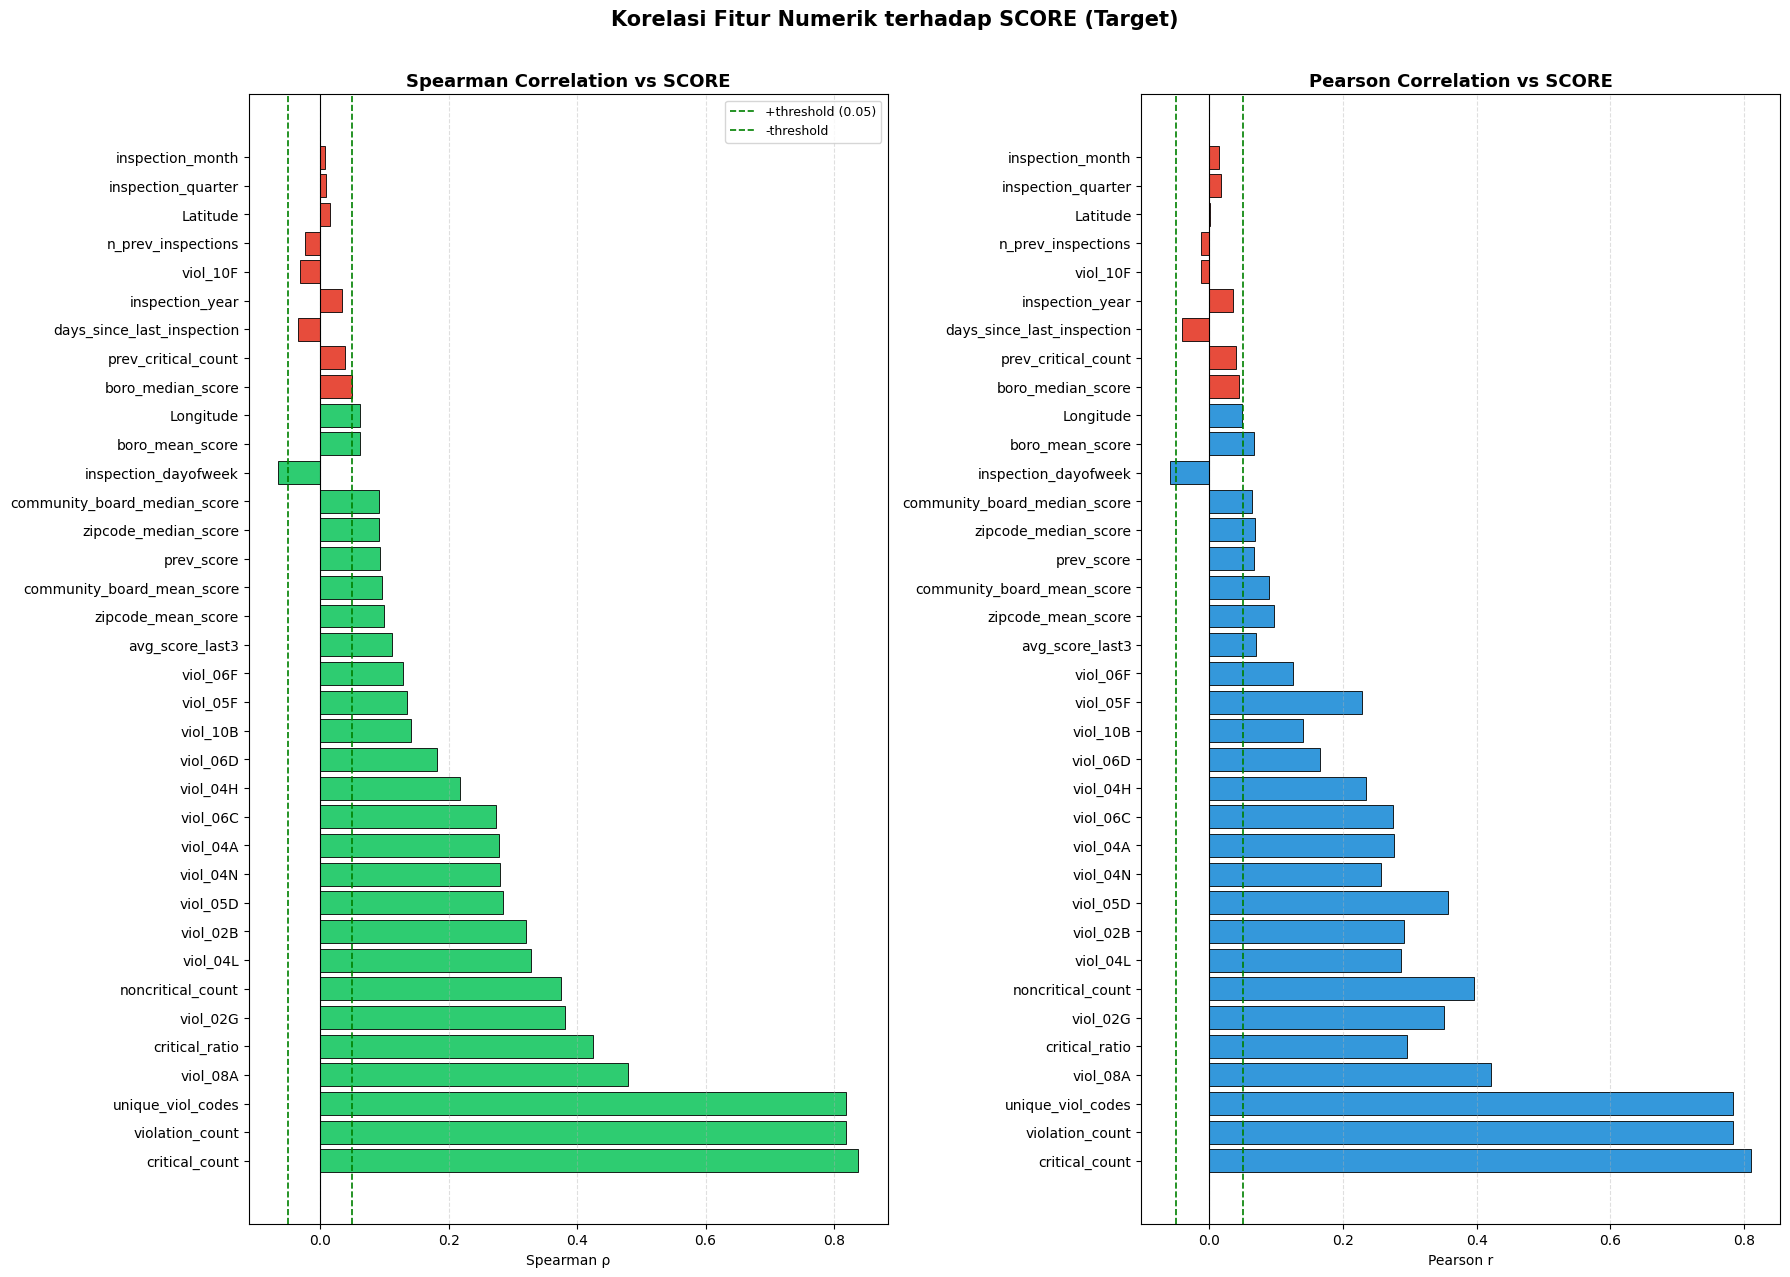


Fitur LEMAH (akan dipertimbangkan untuk di-drop):
['boro_median_score', 'prev_critical_count', 'days_since_last_inspection', 'inspection_year', 'viol_10F', 'n_prev_inspections', 'Latitude', 'inspection_quarter', 'inspection_month']

Fitur KUAT (dipertahankan):
['critical_count', 'violation_count', 'unique_viol_codes', 'viol_08A', 'critical_ratio', 'viol_02G', 'noncritical_count', 'viol_04L', 'viol_02B', 'viol_05D', 'viol_04N', 'viol_04A', 'viol_06C', 'viol_04H', 'viol_06D', 'viol_10B', 'viol_05F', 'viol_06F', 'avg_score_last3', 'zipcode_mean_score', 'community_board_mean_score', 'prev_score', 'zipcode_median_score', 'community_board_median_score', 'inspection_dayofweek', 'boro_mean_score', 'Longitude']


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(df_corr) * 0.35)))

colors_sp = ["#2ecc71" if k else "#e74c3c" for k in df_corr["keep"]]
axes[0].barh(df_corr["feature"], df_corr["spearman_r"], color=colors_sp, edgecolor="black", linewidth=0.6)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].axvline( SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2, label=f"+threshold ({SPEARMAN_THRESHOLD})")
axes[0].axvline(-SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2, label=f"-threshold")
axes[0].set_title("Spearman Correlation vs SCORE", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Spearman ρ")
axes[0].legend(fontsize=9)
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

colors_pe = ["#3498db" if k else "#e74c3c" for k in df_corr["keep"]]
axes[1].barh(df_corr["feature"], df_corr["pearson_r"], color=colors_pe, edgecolor="black", linewidth=0.6)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].axvline( SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2)
axes[1].axvline(-SPEARMAN_THRESHOLD, color="green", linestyle="--", linewidth=1.2)
axes[1].set_title("Pearson Correlation vs SCORE", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Pearson r")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Korelasi Fitur Numerik terhadap SCORE (Target)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nFitur LEMAH (akan dipertimbangkan untuk di-drop):")
print(df_corr[~df_corr["keep"]]["feature"].tolist())
print("\nFitur KUAT (dipertahankan):")
print(df_corr[df_corr["keep"]]["feature"].tolist())


In [ ]:
cat_cols_to_check = [
    "BORO", "CUISINE_DESCRIPTION", "INSPECTION TYPE", "ZIPCODE", "Community_Board"
]

eta_results = []
for col in cat_cols_to_check:
    tmp = df_base[[col, "SCORE"]].dropna().copy()
    tmp[col] = tmp[col].astype(str)

    groups = [grp["SCORE"].values for _, grp in tmp.groupby(col) if len(grp) >= 5]
    if len(groups) < 2:
        continue

    f_stat, p_val = stats.f_oneway(*groups)

    grand_mean = tmp["SCORE"].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total   = sum((tmp["SCORE"] - grand_mean)**2)
    eta_sq     = ss_between / ss_total if ss_total > 0 else 0

    eta_results.append({
        "feature":    col,
        "f_stat":     round(f_stat, 4),
        "p_value":    round(p_val, 6),
        "eta_squared": round(eta_sq, 6),
        "n_categories": tmp[col].nunique(),
    })

df_eta = (
    pd.DataFrame(eta_results)
    .sort_values("eta_squared", ascending=False)
    .reset_index(drop=True)
)

ETA_THRESHOLD = 0.01
df_eta["keep"] = df_eta["eta_squared"] >= ETA_THRESHOLD
df_eta["effect_size"] = df_eta["eta_squared"].apply(
    lambda x: "Large (η²≥0.14)" if x >= 0.14
    else "Medium (η²≥0.06)" if x >= 0.06
    else "Small (η²≥0.01)" if x >= 0.01
    else "Negligible"
)

print(f"Total fitur kategorikal diperiksa: {len(df_eta)}")
print()
df_eta


Total fitur kategorikal diperiksa: 5



,feature,f_stat,p_value,eta_squared,n_categories,keep,effect_size
0,CUISINE_DESCRIPTION,112.4816,0.0,0.023922,16,True,Small (η²≥0.01)
1,INSPECTION TYPE,288.1229,0.0,0.020494,6,True,Small (η²≥0.01)
2,ZIPCODE,6.5192,0.0,0.018733,230,True,Small (η²≥0.01)
3,Community_Board,11.8809,0.0,0.011102,70,True,Small (η²≥0.01)
4,BORO,45.3612,0.0,0.003283,6,False,Negligible


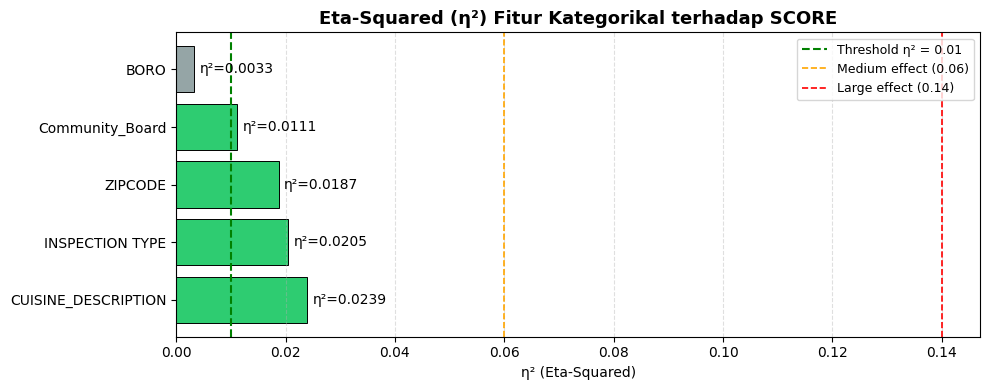

In [ ]:
fig, ax = plt.subplots(figsize=(10, max(4, len(df_eta) * 0.7)))

color_map = {
    "Large (η²≥0.14)":   "#c0392b",
    "Medium (η²≥0.06)":  "#e67e22",
    "Small (η²≥0.01)":   "#2ecc71",
    "Negligible":         "#95a5a6",
}
bar_colors = [color_map[e] for e in df_eta["effect_size"]]

bars = ax.barh(df_eta["feature"], df_eta["eta_squared"],
               color=bar_colors, edgecolor="black", linewidth=0.7)
ax.axvline(ETA_THRESHOLD, color="green", linestyle="--", linewidth=1.5,
           label=f"Threshold η² = {ETA_THRESHOLD}")
ax.axvline(0.06, color="orange", linestyle="--", linewidth=1.2, label="Medium effect (0.06)")
ax.axvline(0.14, color="red",    linestyle="--", linewidth=1.2, label="Large effect (0.14)")

for bar, val in zip(bars, df_eta["eta_squared"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"η²={val:.4f}", va="center", fontsize=10)

ax.set_title("Eta-Squared (η²) Fitur Kategorikal terhadap SCORE", fontsize=13, fontweight="bold")
ax.set_xlabel("η² (Eta-Squared)")
ax.legend(fontsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
print("=" * 65)
print("  REKOMENDASI FITUR BERDASARKAN KORELASI")
print("=" * 65)

keep_num  = df_corr[df_corr["keep"]]["feature"].tolist()
drop_num  = df_corr[~df_corr["keep"]]["feature"].tolist()
keep_cat  = df_eta[df_eta["keep"]]["feature"].tolist()
drop_cat  = df_eta[~df_eta["keep"]]["feature"].tolist()

print(f"\nFitur NUMERIK dipertahankan ({len(keep_num)}):")
for f in keep_num:
    row = df_corr[df_corr["feature"] == f].iloc[0]
    print(f"   {f:<40} ρ={row['spearman_r']:+.4f}  p={row['spearman_p']:.4f}")

print(f"\nFitur NUMERIK lemah — pertimbangkan DROP ({len(drop_num)}):")
for f in drop_num:
    row = df_corr[df_corr["feature"] == f].iloc[0]
    print(f"   {f:<40} ρ={row['spearman_r']:+.4f}  p={row['spearman_p']:.4f}")

print(f"\nFitur KATEGORIKAL dipertahankan ({len(keep_cat)}):")
for f in keep_cat:
    row = df_eta[df_eta["feature"] == f].iloc[0]
    print(f"   {f:<40} η²={row['eta_squared']:.4f}  ({row['effect_size']})")

print(f"\nFitur KATEGORIKAL lemah — pertimbangkan DROP ({len(drop_cat)}):")
for f in drop_cat:
    row = df_eta[df_eta["feature"] == f].iloc[0]
    print(f"   {f:<40} η²={row['eta_squared']:.4f}  ({row['effect_size']})")

recommended_num = keep_num
recommended_cat = keep_cat
print(f"\n{'='*65}")
print(f"  TOTAL FITUR DIREKOMENDASIKAN: {len(recommended_num) + len(recommended_cat)}")
print(f"  Numerik: {len(recommended_num)}  |  Kategorikal: {len(recommended_cat)}")
print(f"{'='*65}")


  REKOMENDASI FITUR BERDASARKAN KORELASI

Fitur NUMERIK dipertahankan (27):
   critical_count                           ρ=+0.8381  p=0.0000
   violation_count                          ρ=+0.8187  p=0.0000
   unique_viol_codes                        ρ=+0.8187  p=0.0000
   viol_08A                                 ρ=+0.4795  p=0.0000
   critical_ratio                           ρ=+0.4245  p=0.0000
   viol_02G                                 ρ=+0.3808  p=0.0000
   noncritical_count                        ρ=+0.3756  p=0.0000
   viol_04L                                 ρ=+0.3289  p=0.0000
   viol_02B                                 ρ=+0.3208  p=0.0000
   viol_05D                                 ρ=+0.2845  p=0.0000
   viol_04N                                 ρ=+0.2806  p=0.0000
   viol_04A                                 ρ=+0.2784  p=0.0000
   viol_06C                                 ρ=+0.2740  p=0.0000
   viol_04H                                 ρ=+0.2171  p=0.0000
   viol_06D                 

In [ ]:
FINAL_NUM_FEATURES = recommended_num + ['days_since_last_inspection']
FINAL_CAT_FEATURES = recommended_cat

print("Daftar fitur numerik final:")
print(FINAL_NUM_FEATURES)
print()
print("Daftar fitur kategorikal final:")
print(FINAL_CAT_FEATURES)


Daftar fitur numerik final:
['critical_count', 'violation_count', 'unique_viol_codes', 'viol_08A', 'critical_ratio', 'viol_02G', 'noncritical_count', 'viol_04L', 'viol_02B', 'viol_05D', 'viol_04N', 'viol_04A', 'viol_06C', 'viol_04H', 'viol_06D', 'viol_10B', 'viol_05F', 'viol_06F', 'avg_score_last3', 'zipcode_mean_score', 'community_board_mean_score', 'prev_score', 'zipcode_median_score', 'community_board_median_score', 'inspection_dayofweek', 'boro_mean_score', 'Longitude', 'days_since_last_inspection']

Daftar fitur kategorikal final:
['CUISINE_DESCRIPTION', 'INSPECTION TYPE', 'ZIPCODE', 'Community_Board']


## Step 5 - Apply Drop Fitur Lemah Berdasarkan Correlation Analysis ##

**Keputusan drop berdasarkan hasil korelasi:**

| Fitur | Alasan Drop |
|---|---|
| `inspection_month`, `inspection_quarter`, `inspection_year` | ρ < 0.04, tidak ada pola temporal signifikan |
| `inspection_dayofweek` | ρ = -0.066, lolos tipis tapi makna meragukan |
| `Latitude` | ρ = 0.016, sangat lemah — Longitude lebih diskriminatif |
| `BORO` | η² = 0.003 (Negligible) — sudah ter-capture di `boro_mean_score` |
| `boro_median_score` | ρ = 0.042, di bawah threshold — pakai `boro_mean_score` saja |
| `prev_critical_count` | ρ = 0.038, redundan dengan `critical_count` saat ini |
| `n_prev_inspections` | ρ = -0.023, tidak prediktif |
| `viol_10F` | ρ = -0.031, frekuensi tinggi di EDA tapi tidak diskriminatif untuk score |
| `ever_had_critical` | Boolean lemah, sudah di-cover oleh `has_critical` & `critical_count` |


In [ ]:
cols_to_drop = [
    "inspection_month",
    "inspection_quarter",
    "inspection_year",
    "inspection_dayofweek",
    "Latitude",
    "boro_median_score",
    "BORO",
    "prev_critical_count",
    "n_prev_inspections",
    "days_since_last_inspection",
    "ever_had_critical",
    "viol_10F",
]

cols_to_drop_exist = [c for c in cols_to_drop if c in df_base.columns]
cols_not_found     = [c for c in cols_to_drop if c not in df_base.columns]

df_base = df_base.drop(columns=cols_to_drop_exist)

print(f"Kolom di-drop ({len(cols_to_drop_exist)}): {cols_to_drop_exist}")
if cols_not_found:
    print(f"Tidak ditemukan (skip): {cols_not_found}")
print(f"\nShape df_base setelah drop: {df_base.shape}")
print(f"\nKolom tersisa ({len(df_base.columns)}):")
print(df_base.columns.tolist())


Kolom di-drop (12): ['inspection_month', 'inspection_quarter', 'inspection_year', 'inspection_dayofweek', 'Latitude', 'boro_median_score', 'BORO', 'prev_critical_count', 'n_prev_inspections', 'days_since_last_inspection', 'ever_had_critical', 'viol_10F']

Shape df_base setelah drop: (68860, 34)

Kolom tersisa (34):
['CAMIS', 'INSPECTION DATE', 'SCORE', 'CUISINE_DESCRIPTION', 'ZIPCODE', 'Longitude', 'Community_Board', 'INSPECTION TYPE', 'critical_count', 'has_critical', 'noncritical_count', 'violation_count', 'unique_viol_codes', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'viol_10B', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_mean_score', 'zipcode_median_score', 'community_board_mean_score', 'community_board_median_score']


## Step 6 - Advanced Preprocessing: Encoding Variabel Kategorikal ##

**Strategi encoding berdasarkan hasil korelasi:**

| Fitur | Strategi | Alasan |
|---|---|---|
| `INSPECTION TYPE` | **One-Hot Encoding** | 6 kategori (top 5 + Other), η²=0.021 |
| `ZIPCODE` | **Drop raw** → sudah ada `zipcode_mean_score` & `zipcode_median_score` | Ratusan kategori, encoding numeriknya lebih informatif |
| `Community_Board` | **Drop raw** → sudah ada `community_board_median_score` | Sama seperti ZIPCODE |

**Catatan:** `CAMIS` dan `INSPECTION DATE` adalah identifier — tidak ikut di-encode, di-drop sebelum modeling.


In [ ]:
ohe_cols = ["INSPECTION TYPE"]

df_encoded = pd.get_dummies(
    df_base,
    columns=ohe_cols,
    prefix={"INSPECTION TYPE": "instype"},
    drop_first=False,   
    dtype=int           
)

print(f"Shape sebelum OHE: {df_base.shape}")
print(f"Shape setelah OHE: {df_encoded.shape}")
print(f"Kolom baru dari OHE ({df_encoded.shape[1] - df_base.shape[1]}):")
new_ohe_cols = [c for c in df_encoded.columns if c.startswith("cuisine_") or c.startswith("instype_")]
print(new_ohe_cols)

Shape sebelum OHE: (68860, 34)
Shape setelah OHE: (68860, 39)
Kolom baru dari OHE (5):
['instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Other', 'instype_Pre-permit (Operational) / Initial Inspection', 'instype_Pre-permit (Operational) / Re-inspection']


In [ ]:
raw_cat_to_drop = ["ZIPCODE", "Community_Board", "CUISINE_DESCRIPTION"]
id_cols         = ["CAMIS", "INSPECTION DATE"]

df_ids = df_encoded[id_cols].copy()

df_encoded = df_encoded.drop(
    columns=[c for c in raw_cat_to_drop + id_cols if c in df_encoded.columns]
)

print(f"Shape df_encoded setelah drop kolom raw: {df_encoded.shape}")
print()
print("Kolom final df_encoded:")
print(df_encoded.columns.tolist())

Shape df_encoded setelah drop kolom raw: (68860, 34)

Kolom final df_encoded:
['SCORE', 'Longitude', 'critical_count', 'has_critical', 'noncritical_count', 'violation_count', 'unique_viol_codes', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'viol_10B', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_mean_score', 'zipcode_median_score', 'community_board_mean_score', 'community_board_median_score', 'instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Other', 'instype_Pre-permit (Operational) / Initial Inspection', 'instype_Pre-permit (Operational) / Re-inspection']


In [ ]:
df_encoded["has_critical"] = df_encoded["has_critical"].astype(int)

non_numeric = df_encoded.select_dtypes(exclude="number").columns.tolist()

if non_numeric:
    print(f"Masih ada kolom non-numerik: {non_numeric}")
    print("Perlu ditangani sebelum modeling!")
else:
    print("Semua kolom sudah numerik — df_encoded siap untuk tahap scaling & modeling")

print(f"\nShape final: {df_encoded.shape}")
print(f"Missing values total: {df_encoded.isna().sum().sum()}")
print()
print("=== Dtypes summary ===")
print(df_encoded.dtypes.value_counts())
print()
print("=== Preview 5 baris pertama ===")
df_encoded.head()

Semua kolom sudah numerik — df_encoded siap untuk tahap scaling & modeling

Shape final: (68860, 34)
Missing values total: 0

=== Dtypes summary ===
float64    27
int64       7
Name: count, dtype: int64

=== Preview 5 baris pertama ===


,SCORE,Longitude,critical_count,has_critical,noncritical_count,violation_count,unique_viol_codes,critical_ratio,viol_02B,viol_02G,viol_04A,viol_04H,viol_04L,viol_04N,viol_05D,viol_05F,viol_06C,viol_06D,viol_06F,viol_08A,viol_10B,prev_score,avg_score_last3,boro_mean_score,zipcode_mean_score,zipcode_median_score,community_board_mean_score,community_board_median_score,instype_Cycle Inspection / Initial Inspection,instype_Cycle Inspection / Re-inspection,instype_Cycle Inspection / Reopening Inspection,instype_Other,instype_Pre-permit (Operational) / Initial Inspection,instype_Pre-permit (Operational) / Re-inspection
28286,13.0,-73.844604,1.0,1,1.0,2.0,2.0,0.500000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,13.0,17.384430,18.018182,13.0,17.594313,13.0,1,0,0,0,0,0
44139,12.0,-73.951096,1.0,1,2.0,3.0,3.0,0.333333,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0,13.0,17.723636,19.514851,12.0,9.600000,12.0,0,1,0,0,0,0
4697,2.0,-73.978370,0.0,0,1.0,1.0,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,13.0,18.158726,16.345588,12.0,17.113572,12.0,1,0,0,0,0,0
28080,2.0,-73.988206,0.0,0,1.0,1.0,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,13.0,2.000000,18.298113,13.0,2.000000,2.0,1,0,0,0,0,0
40124,4.0,-73.846616,0.0,0,2.0,2.0,2.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,13.0,13.000000,13.000000,13.0,13.000000,13.0,0,0,0,0,1,0


In [ ]:
from scipy.stats.mstats import winsorize

cols_to_winsorize = [
    "violation_count", "critical_count", "noncritical_count",
    "unique_viol_codes", "critical_ratio"
]

for col in cols_to_winsorize:
    upper = df_encoded[col].quantile(0.99)
    df_encoded[col] = df_encoded[col].clip(upper=upper)
    print(f"{col:<25} capped at P99 = {upper:.2f}")

print("\nWinsorize fitur numerik selesai")

violation_count           capped at P99 = 10.00
critical_count            capped at P99 = 7.00
noncritical_count         capped at P99 = 4.00
unique_viol_codes         capped at P99 = 10.00
critical_ratio            capped at P99 = 1.00

Winsorize fitur numerik selesai


In [ ]:
skew_df = (
    df_encoded[[c for c in df_encoded.columns
                if not any(c.startswith(p) for p in 
                          ["cuisine_", "instype_", "viol_"])
                and c not in ["has_critical", "SCORE"]]]
    .skew()
    .abs()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", 0: "abs_skewness"})
)

skew_df["perlu_log"] = skew_df["abs_skewness"] > 1.0  

print(skew_df.to_string(index=False))

                     feature  abs_skewness  perlu_log
        zipcode_median_score      6.455681       True
community_board_median_score      6.093655       True
          zipcode_mean_score      1.381656       True
              critical_count      1.120576       True
             boro_mean_score      1.051210       True
             violation_count      1.007890       True
           unique_viol_codes      1.007890       True
           noncritical_count      0.536622      False
  community_board_mean_score      0.434554      False
             avg_score_last3      0.401437      False
                  prev_score      0.384908      False
                   Longitude      0.206318      False
              critical_ratio      0.129107      False


In [ ]:
for col in ["critical_count", "violation_count", "unique_viol_codes"]:
    df_encoded[col] = np.log1p(df_encoded[col])
    print(f"{col} → log1p applied")

critical_count → log1p applied
violation_count → log1p applied
unique_viol_codes → log1p applied


Total fitur masuk modeling: 33
Fitur dengan |ρ| ≥ 0.05: 30
Fitur dengan |ρ| < 0.05: 3



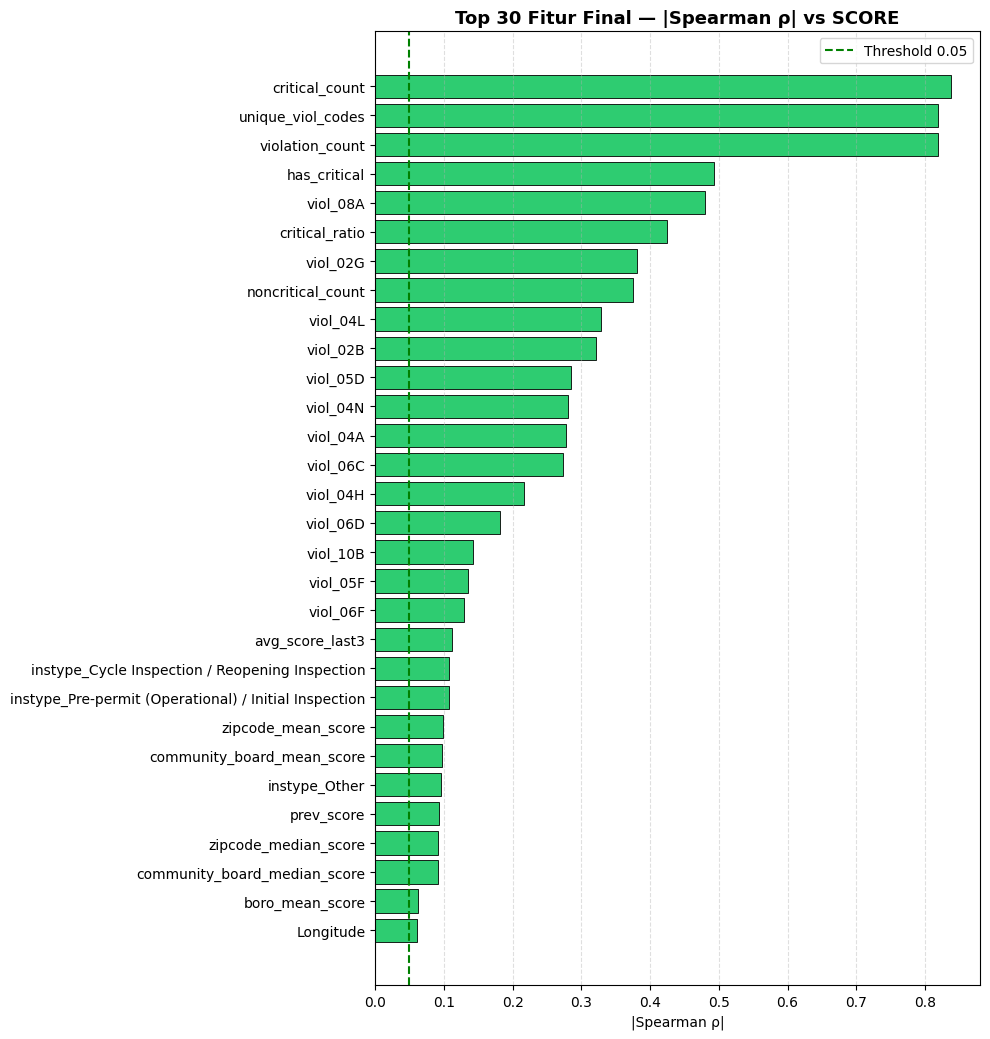


=== Top 10 fitur paling prediktif ===
          feature  abs_spearman_rho
   critical_count          0.838132
unique_viol_codes          0.818710
  violation_count          0.818710
     has_critical          0.492786
         viol_08A          0.479486
   critical_ratio          0.424466
         viol_02G          0.380793
noncritical_count          0.375468
         viol_04L          0.328939
         viol_02B          0.320815


In [ ]:
final_corr = (
    df_encoded.corr(method="spearman")["SCORE"]
    .drop("SCORE")
    .abs()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", "SCORE": "abs_spearman_rho"})
)

print(f"Total fitur masuk modeling: {len(final_corr)}")
print(f"Fitur dengan |ρ| ≥ 0.05: {(final_corr['abs_spearman_rho'] >= 0.05).sum()}")
print(f"Fitur dengan |ρ| < 0.05: {(final_corr['abs_spearman_rho'] < 0.05).sum()}")
print()

top_n = min(30, len(final_corr))
plot_df = final_corr.head(top_n)

fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.35)))
colors = ["#2ecc71" if v >= 0.05 else "#e74c3c" for v in plot_df["abs_spearman_rho"]]
ax.barh(plot_df["feature"], plot_df["abs_spearman_rho"],
        color=colors, edgecolor="black", linewidth=0.6)
ax.axvline(0.05, color="green", linestyle="--", linewidth=1.5, label="Threshold 0.05")
ax.set_title(f"Top {top_n} Fitur Final — |Spearman ρ| vs SCORE", fontsize=13, fontweight="bold")
ax.set_xlabel("|Spearman ρ|")
ax.legend()
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n=== Top 10 fitur paling prediktif ===")
print(final_corr.head(10).to_string(index=False))

## Step 7 - Advanced Preprocessing: Handling Outlier pada SCORE ##

**Konteks dari EDA:**
- Distribusi SCORE **right-skewed** — mayoritas score berkumpul di 0–25, ada ekor panjang ke kanan
- Outlier score tinggi tetap **informatif** — bukan noise, melainkan inspeksi berisiko tinggi

**Strategi: Winsorize dulu → lalu Log1p Transform**

| Teknik | Fungsi | Urutan |
|---|---|---|
| **Winsorize (P99)** | Potong nilai ekstrem agar tidak mendominasi log scale | 1️⃣ |
| **Log1p Transform** | Perbaiki right-skewness distribusi → mendekati normal | 2️⃣ |

Mengapa log1p dan bukan log biasa? Karena SCORE bisa bernilai **0** → `log(0) = -inf`.
`log1p(x) = log(x + 1)` aman untuk nilai 0.

⚠️ **Konsekuensi:** Prediksi model akan dalam skala log → saat evaluasi dan interpretasi,
hasil prediksi harus dikembalikan ke skala asli dengan `np.expm1(y_pred)`.


=== Statistik SCORE (sebelum handling) ===
Min    : 0.0
Q1     : 9.0
Median : 13.0
Mean   : 18.12
Q3     : 24.0
P95    : 47.0
P99    : 73.0
Max    : 203.0
Skewness: 2.209

Outlier (IQR): 3,628 baris (5.3%)
Outlier ekstrem (>P99=73.0): 654 baris


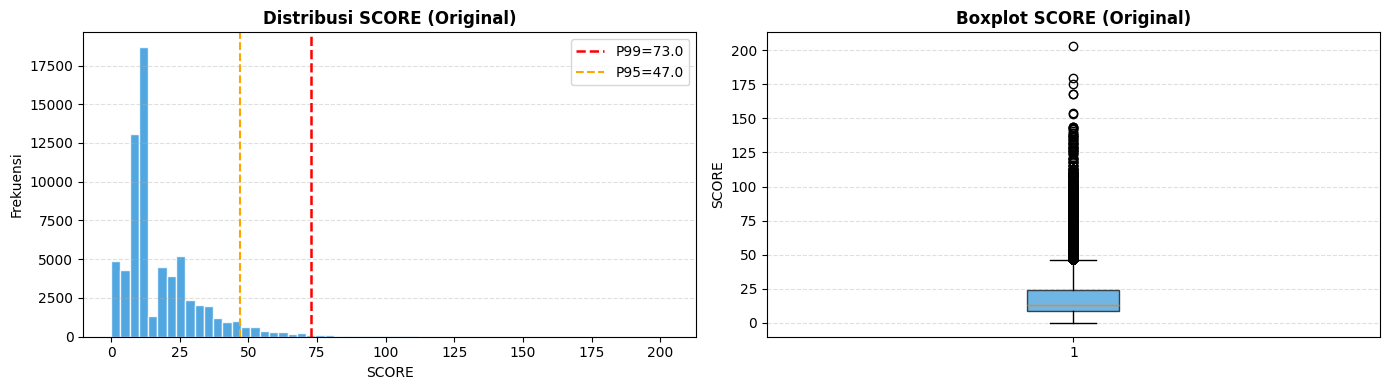

In [ ]:
score = df_encoded["SCORE"]

q1  = score.quantile(0.25)
q3  = score.quantile(0.75)
iqr = q3 - q1
p99 = score.quantile(0.99)
p95 = score.quantile(0.95)

print("=== Statistik SCORE (sebelum handling) ===")
print(f"Min    : {score.min():.1f}")
print(f"Q1     : {q1:.1f}")
print(f"Median : {score.median():.1f}")
print(f"Mean   : {score.mean():.2f}")
print(f"Q3     : {q3:.1f}")
print(f"P95    : {p95:.1f}")
print(f"P99    : {p99:.1f}")
print(f"Max    : {score.max():.1f}")
print(f"Skewness: {score.skew():.3f}")
print(f"\nOutlier (IQR): {(score > q3 + 1.5*iqr).sum():,} baris ({(score > q3 + 1.5*iqr).mean()*100:.1f}%)")
print(f"Outlier ekstrem (>P99={p99:.1f}): {(score > p99).sum():,} baris")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(score, bins=60, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].axvline(p99, color="red",    linestyle="--", linewidth=1.8, label=f"P99={p99:.1f}")
axes[0].axvline(p95, color="orange", linestyle="--", linewidth=1.5, label=f"P95={p95:.1f}")
axes[0].set_title("Distribusi SCORE (Original)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("SCORE"); axes[0].set_ylabel("Frekuensi")
axes[0].legend(); axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].boxplot(score, vert=True, patch_artist=True, boxprops=dict(facecolor="#3498db", alpha=0.7))
axes[1].set_title("Boxplot SCORE (Original)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("SCORE"); axes[1].grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
score_before_transform = df_encoded["SCORE"].copy()

In [ ]:
CAP_PERCENTILE = 0.99
score_cap = df_encoded["SCORE"].quantile(CAP_PERCENTILE)
df_encoded["SCORE"] = df_encoded["SCORE"].clip(upper=score_cap)

print(f"[Winsorize] Cap di P99 = {score_cap:.1f}")
print(f"Baris yang di-cap: {(df_encoded['SCORE'] == score_cap).sum():,}")
print(f"Skewness setelah winsorize: {df_encoded['SCORE'].skew():.3f}")
print()


df_encoded["SCORE"] = np.log1p(df_encoded["SCORE"])

print(f"[Log1p] Transform diterapkan: SCORE = log(SCORE_winsorized + 1)")
print(f"Skewness setelah log1p      : {df_encoded['SCORE'].skew():.3f}")
print(f"Range SCORE sekarang        : [{df_encoded['SCORE'].min():.3f}, {df_encoded['SCORE'].max():.3f}]")
print()


[Winsorize] Cap di P99 = 73.0
Baris yang di-cap: 700
Skewness setelah winsorize: 1.621

[Log1p] Transform diterapkan: SCORE = log(SCORE_winsorized + 1)
Skewness setelah log1p      : -0.714
Range SCORE sekarang        : [0.000, 4.304]



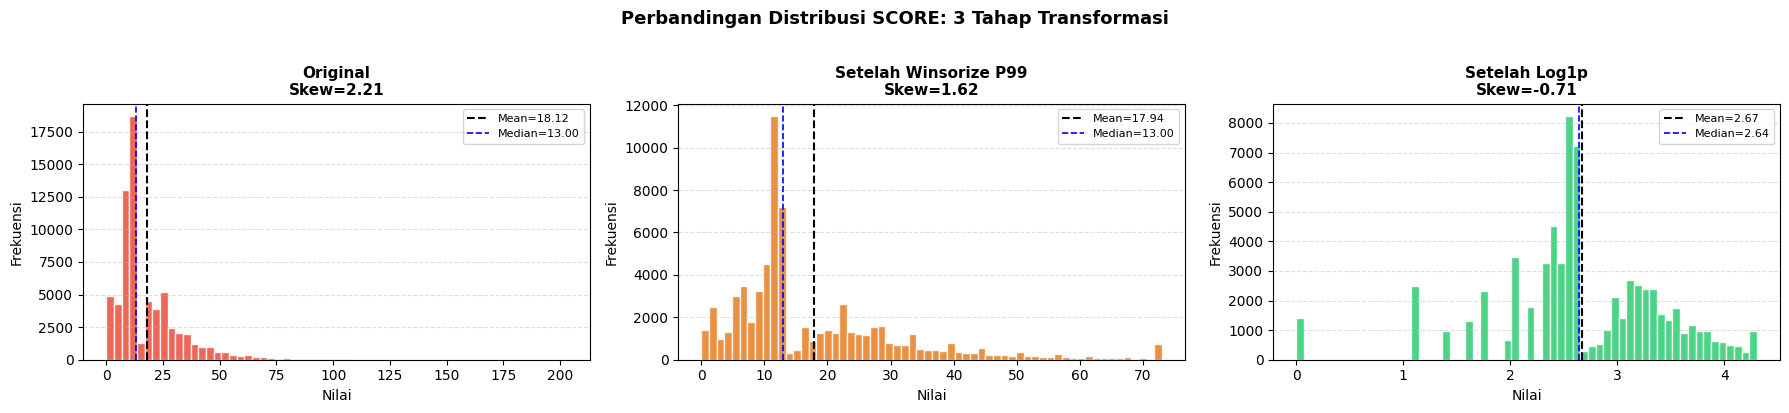

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

score_original  = score_before_transform                          
score_winsorize = score_before_transform.clip(upper=score_cap)   
score_log1p     = df_encoded["SCORE"]                            
data_stages = [
    (score_original,  f"Original",  "#e74c3c"),
    (score_winsorize, f"Setelah Winsorize P99", "#e67e22"),
    (score_log1p,     f"Setelah Log1p", "#2ecc71"),
]

for ax, (data, title, color) in zip(axes, data_stages):
    ax.hist(data, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="black",  linestyle="--", linewidth=1.5,
               label=f"Mean={data.mean():.2f}")
    ax.axvline(data.median(), color="blue",   linestyle="--", linewidth=1.2,
               label=f"Median={data.median():.2f}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Nilai"); ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_title(f"{title}\nSkew={data.skew():.2f}", fontsize=11, fontweight="bold")

plt.suptitle("Perbandingan Distribusi SCORE: 3 Tahap Transformasi",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Step 8 - Advanced Preprocessing: Train-Test Split (Temporal) ##

**Mengapa 3-Way Temporal Split (Train / Validation / Test)?**

| Set | Proporsi | Fungsi |
|---|---|---|
| **Train** | 70% | Melatih model |
| **Validation** | 15% | Tuning hyperparameter, pilih model terbaik |
| **Test** | 15% | Evaluasi final — **hanya disentuh sekali di akhir** |

Kalau hanya pakai train/test dan tuning dilakukan berdasarkan test set → test set "bocor" ke proses
training secara tidak langsung → hasil evaluasi **overly optimistic**, tidak mencerminkan performa di data baru.

Split tetap **temporal** dan berurutan karena data ini time-series inspeksi:
```
[────── Train (70%) ──────────][── Val (15%) ──][── Test (15%) ──]
 terlama                                                  terbaru
```

⚠️  **Target encoding di-refit dari train saja**, lalu di-apply ke val dan test.


In [ ]:
df_split = df_encoded.copy()
df_split["INSPECTION DATE"] = pd.to_datetime(df_ids["INSPECTION DATE"].values)
df_split["CAMIS"]           = df_ids["CAMIS"].values
df_split = df_split.sort_values("INSPECTION DATE").reset_index(drop=True)

n = len(df_split)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_split.iloc[:train_end].copy()
val_df   = df_split.iloc[train_end:val_end].copy()
test_df  = df_split.iloc[val_end:].copy()

print(f"Total data       : {n:,}")
print(f"\nTrain  : {len(train_df):,} baris ({len(train_df)/n*100:.1f}%)")
print(f"  Periode: {train_df['INSPECTION DATE'].min().date()} → {train_df['INSPECTION DATE'].max().date()}")
print(f"\nVal    : {len(val_df):,} baris ({len(val_df)/n*100:.1f}%)")
print(f"  Periode: {val_df['INSPECTION DATE'].min().date()} → {val_df['INSPECTION DATE'].max().date()}")
print(f"\nTest   : {len(test_df):,} baris ({len(test_df)/n*100:.1f}%)")
print(f"  Periode: {test_df['INSPECTION DATE'].min().date()} → {test_df['INSPECTION DATE'].max().date()}")

Total data       : 68,860

Train  : 48,202 baris (70.0%)
  Periode: 2023-03-03 → 2025-05-09

Val    : 10,329 baris (15.0%)
  Periode: 2025-05-09 → 2025-10-07

Test   : 10,329 baris (15.0%)
  Periode: 2025-10-07 → 2026-02-28


In [ ]:
te_map = {
    "zipcode_mean_score":            ("ZIPCODE",         "mean"),
    "zipcode_median_score":          ("ZIPCODE",         "median"),
    "boro_mean_score":               ("BORO",            "mean"),
    "community_board_median_score":  ("Community_Board", "median"),
    "community_board_mean_score":    ("Community_Board", "mean"),
}

camis_geo = (
    df_ins[["CAMIS", "ZIPCODE", "BORO", "Community_Board"]]
    .copy()
    .astype(str)
    .replace("nan", pd.NA)        
    .dropna(subset=["CAMIS"])     
    .groupby("CAMIS", as_index=False)
    .first()                    
)

for df_ in [train_df, val_df, test_df]:
    df_["CAMIS"] = df_["CAMIS"].astype(str)

for geo_col in ["ZIPCODE", "BORO", "Community_Board"]:
    camis_to_geo = camis_geo.set_index("CAMIS")[geo_col]
    for df_ in [train_df, val_df, test_df]:
        df_[geo_col] = df_["CAMIS"].map(camis_to_geo)

global_median_train = train_df["SCORE"].median()

for new_col, (geo_col, agg_fn) in te_map.items():
    if new_col not in train_df.columns:
        continue
    stats_dict = (
        train_df.dropna(subset=[geo_col])
        .groupby(geo_col)["SCORE"]
        .agg(agg_fn)
        .to_dict()
    )
    for df_ in [train_df, val_df, test_df]:
        df_[new_col] = df_[geo_col].map(stats_dict).fillna(global_median_train)

geo_temp_cols = ["ZIPCODE", "BORO", "Community_Board"]
for df_ in [train_df, val_df, test_df]:
    df_.drop(columns=geo_temp_cols, errors="ignore", inplace=True)

print("\u2705 Target encoding di-refit dari train set saja, applied ke val & test")
print(f"\nTrain: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")


✅ Target encoding di-refit dari train set saja, applied ke val & test

Train: (48202, 36) | Val: (10329, 36) | Test: (10329, 36)


In [ ]:
drop_final = ["INSPECTION DATE", "CAMIS"]

X_train = train_df.drop(columns=drop_final + ["SCORE"], errors="ignore")
y_train = train_df["SCORE"]

X_val   = val_df.drop(columns=drop_final + ["SCORE"], errors="ignore")
y_val   = val_df["SCORE"]

X_test  = test_df.drop(columns=drop_final + ["SCORE"], errors="ignore")
y_test  = test_df["SCORE"]

print("=" * 55)
print("  HASIL AKHIR PREPROCESSING")
print("=" * 55)
print(f"X_train : {X_train.shape}  | y mean={y_train.mean():.3f}, std={y_train.std():.3f}")
print(f"X_val   : {X_val.shape}   | y mean={y_val.mean():.3f}, std={y_val.std():.3f}")
print(f"X_test  : {X_test.shape}   | y mean={y_test.mean():.3f}, std={y_test.std():.3f}")
print(f"\nJumlah fitur masuk modeling: {X_train.shape[1]}")
print(f"\ny dalam skala log1p — pakai np.expm1(y_pred) saat evaluasi ke skala asli")
print(f"\nFeature list:")
print(X_train.columns.tolist())


  HASIL AKHIR PREPROCESSING
X_train : (48202, 33)  | y mean=2.667, std=0.769
X_val   : (10329, 33)   | y mean=2.673, std=0.878
X_test  : (10329, 33)   | y mean=2.704, std=0.760

Jumlah fitur masuk modeling: 33

y dalam skala log1p — pakai np.expm1(y_pred) saat evaluasi ke skala asli

Feature list:
['Longitude', 'critical_count', 'has_critical', 'noncritical_count', 'violation_count', 'unique_viol_codes', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'viol_10B', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_mean_score', 'zipcode_median_score', 'community_board_mean_score', 'community_board_median_score', 'instype_Cycle Inspection / Initial Inspection', 'instype_Cycle Inspection / Re-inspection', 'instype_Cycle Inspection / Reopening Inspection', 'instype_Other', 'instype_Pre-permit (Operational) / Initial Inspection', 'instype_Pre-permit (Operational) / Re-i

**Target Encoding untuk Cuisine Description pada masing-masing train, val, dan test**

In [ ]:
camis_cuisine = (
    df_ins[["CAMIS", "CUISINE_DESCRIPTION"]]
    .astype(str)
    .groupby("CAMIS")
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

for df_ in [train_df, val_df, test_df]:
    df_["CAMIS"] = df_["CAMIS"].astype(str)

camis_to_cuisine = camis_cuisine.set_index("CAMIS")["CUISINE_DESCRIPTION"]
train_df["CUISINE_DESCRIPTION"] = train_df["CAMIS"].map(camis_to_cuisine)
val_df["CUISINE_DESCRIPTION"]   = val_df["CAMIS"].map(camis_to_cuisine)
test_df["CUISINE_DESCRIPTION"]  = test_df["CAMIS"].map(camis_to_cuisine)

global_median = train_df["SCORE"].median()
cuisine_mean  = train_df.groupby("CUISINE_DESCRIPTION")["SCORE"].mean().to_dict()

for df_, X_ in [(train_df, X_train), (val_df, X_val), (test_df, X_test)]:
    X_["cuisine_encoded"] = df_["CUISINE_DESCRIPTION"].map(cuisine_mean).fillna(global_median)

for df_ in [train_df, val_df, test_df]:
    df_.drop(columns=["CUISINE_DESCRIPTION"], errors="ignore", inplace=True)

print("✅ Target encoding CUISINE_DESCRIPTION selesai")
print(f"Jumlah kategori cuisine : {len(cuisine_mean)}")
print(f"Sample nilai encoding   : {dict(list(cuisine_mean.items())[:5])}")

✅ Target encoding CUISINE_DESCRIPTION selesai
Jumlah kategori cuisine : 90
Sample nilai encoding   : {'Afghan': 2.833123504308041, 'African': 2.98006820811021, 'American': 2.588143369693703, 'Armenian': 2.802479903522276, 'Asian/Asian Fusion': 2.848377820941733}


## Step 9 - Advanced Preprocessing: Feature Scaling ##

**Strategi Scaling:**

| Kolom | Scaler | Alasan |
|---|---|---|
| `SCORE` (target) | **Tidak di-scale** | Target regresi dibiarkan asli agar prediksi tetap interpretable |
| Fitur numerik kontinyu (score historis, koordinat, dll) | **RobustScaler** | Tahan terhadap outlier — menggunakan median & IQR bukan mean & std |
| Fitur count (violation_count, critical_count, dll) | **RobustScaler** | Distribusinya skewed, RobustScaler lebih aman |
| Fitur binary OHE (`cuisine_*`, `instype_*`, `viol_*`, `has_critical`) | **Tidak di-scale** | Sudah 0/1, scaling justru merusak interpretasi |

**Mengapa RobustScaler bukan StandardScaler?**
SCORE dan violation features punya outlier signifikan. StandardScaler akan terpengaruh mean & std yang terdistorsi outlier, sehingga fitur normal jadi ter-compress. RobustScaler memakai median & IQR sehingga lebih stabil.


In [ ]:
from sklearn.preprocessing import RobustScaler

binary_cols = (
    [c for c in X_train.columns if c.startswith("cuisine_")]
    + [c for c in X_train.columns if c.startswith("instype_")]
    + [c for c in X_train.columns if c.startswith("viol_")]
    + ["has_critical"]
)
binary_cols = [c for c in binary_cols if c in X_train.columns]

scale_cols = [
    c for c in X_train.select_dtypes(include="number").columns
    if c not in binary_cols
]

scaler = RobustScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])   
X_val[scale_cols]   = scaler.transform(X_val[scale_cols])          
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])         

print(f"✅ RobustScaler di-fit dari train, applied ke val & test")
print(f"Kolom di-scale ({len(scale_cols)}): {scale_cols}")

✅ RobustScaler di-fit dari train, applied ke val & test
Kolom di-scale (13): ['Longitude', 'critical_count', 'noncritical_count', 'violation_count', 'unique_viol_codes', 'critical_ratio', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_mean_score', 'zipcode_median_score', 'community_board_mean_score', 'community_board_median_score']


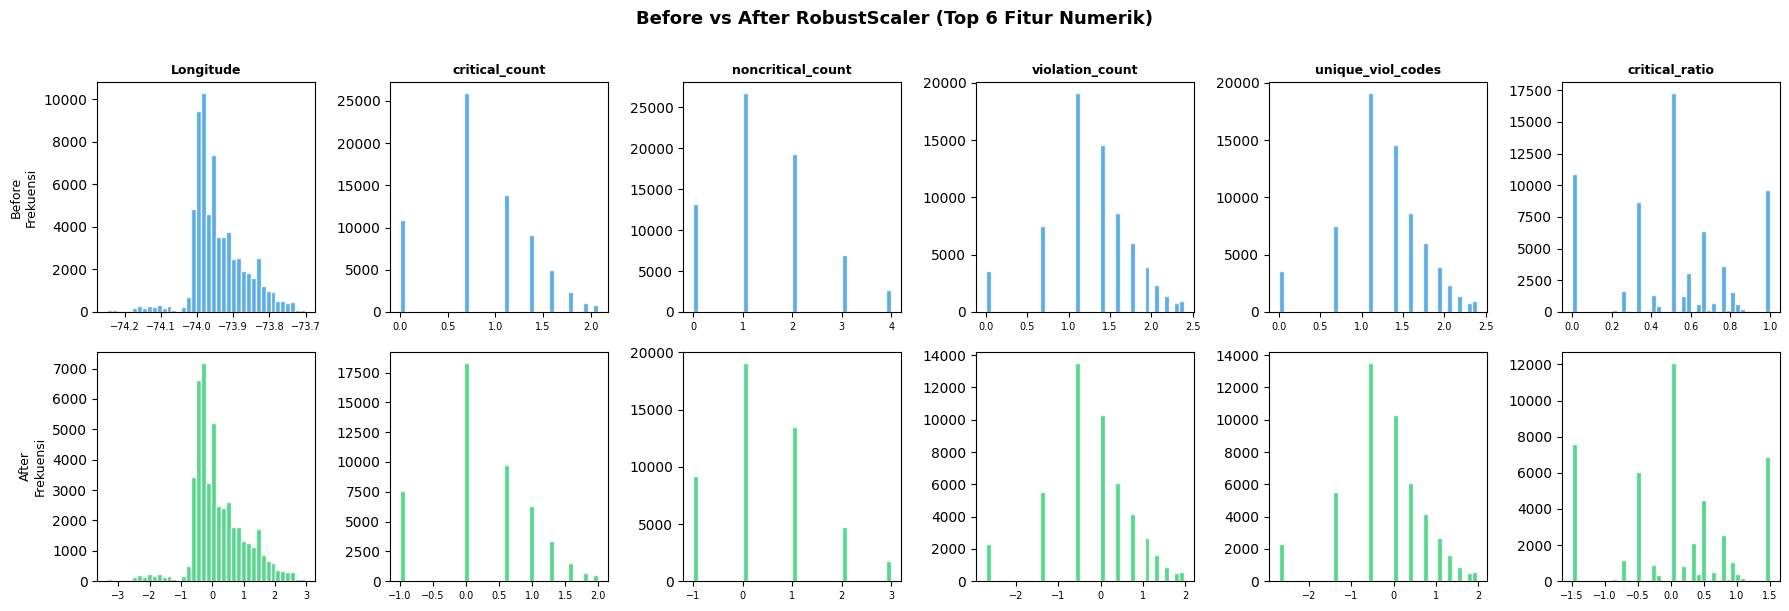

In [ ]:
top6_scale = [c for c in X_train.columns if c in scale_cols][:6]

df_before = df_encoded[top6_scale].copy()

fig, axes = plt.subplots(2, len(top6_scale), figsize=(18, 6))

for i, col in enumerate(top6_scale):
    axes[0, i].hist(df_before[col].dropna(), bins=40,
                    color="#3498db", edgecolor="white", alpha=0.8)
    axes[0, i].set_title(col, fontsize=9, fontweight="bold")
    axes[0, i].tick_params(axis="x", labelsize=7)
    if i == 0: axes[0, i].set_ylabel("Before\nFrekuensi", fontsize=9)

    axes[1, i].hist(X_train[col].dropna(), bins=40,
                    color="#2ecc71", edgecolor="white", alpha=0.8)
    axes[1, i].tick_params(axis="x", labelsize=7)
    if i == 0: axes[1, i].set_ylabel("After\nFrekuensi", fontsize=9)

plt.suptitle("Before vs After RobustScaler (Top 6 Fitur Numerik)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

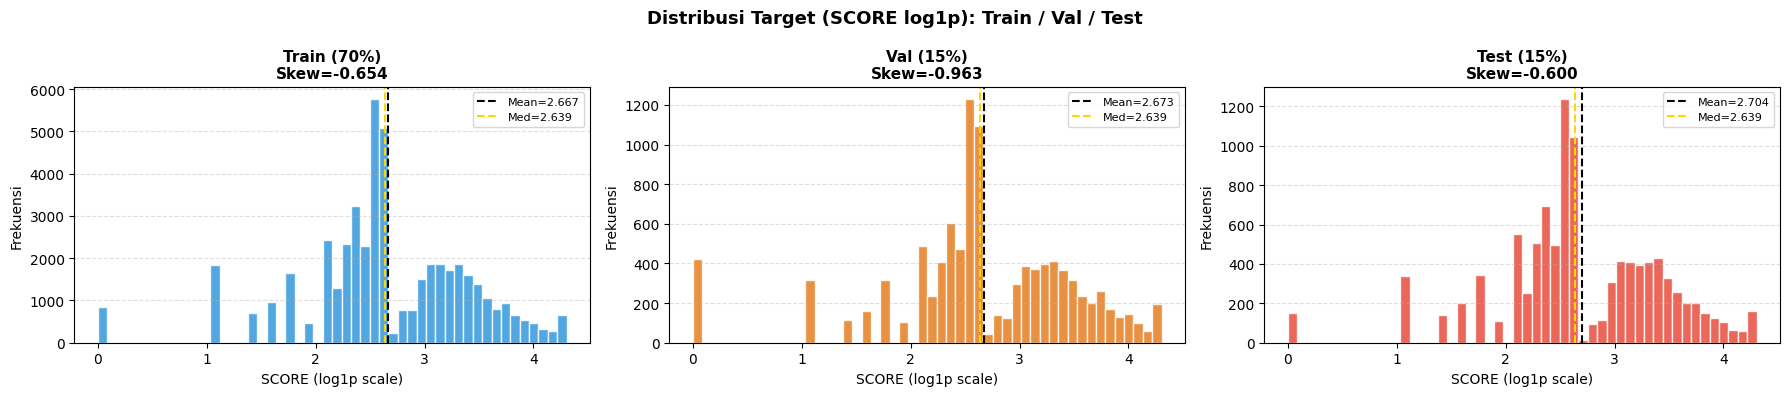

Cek: distribusi ketiga set harus mirip
Train skewness : -0.654
Val   skewness : -0.963
Test  skewness : -0.600


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sets = [
    (y_train, "Train (70%)",  "#3498db"),
    (y_val,   "Val (15%)",    "#e67e22"),
    (y_test,  "Test (15%)",   "#e74c3c"),
]

for ax, (data, label, color) in zip(axes, sets):
    ax.hist(data, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="black", linestyle="--", linewidth=1.5,
               label=f"Mean={data.mean():.3f}")
    ax.axvline(data.median(), color="gold",  linestyle="--", linewidth=1.5,
               label=f"Med={data.median():.3f}")
    ax.set_title(f"{label}\nSkew={data.skew():.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("SCORE (log1p scale)"); ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8); ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Distribusi Target (SCORE log1p): Train / Val / Test",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Cek: distribusi ketiga set harus mirip")
print(f"Train skewness : {y_train.skew():.3f}")
print(f"Val   skewness : {y_val.skew():.3f}")
print(f"Test  skewness : {y_test.skew():.3f}")


## Step 10 - Advanced Preprocessing: Geospatial Density Features ##

**Hasil eksperimen menunjukkan:** Geospatial Density radius **1km** memberikan peningkatan konsisten
pada semua 4 model (Avg Val R² +0.0006) dengan tidak ada model yang memburuk.

**Fitur yang ditambahkan:**
- `density_high_1000m` — jumlah inspeksi restoran dengan SCORE > P75 dalam radius 1km dari lokasi inspeksi ini
- `density_mean_1000m` — rata-rata SCORE restoran tetangga dalam radius 1km

**Anti-leakage:** BallTree dibangun dari **koordinat train set saja**. Val dan test set hanya di-query, tidak ikut membangun tree.

**Catatan:** Restoran tanpa koordinat valid (Latitude/Longitude) di-fill dengan nilai median — baris ini tidak hilang dari dataset.


In [ ]:
from sklearn.neighbors import BallTree

print("Menghitung Geospatial Density Features (radius 1km)...")

df_geo = df_ins[["CAMIS", "Latitude", "Longitude", "SCORE"]].copy()
df_geo["Latitude"]  = pd.to_numeric(df_geo["Latitude"],  errors="coerce")
df_geo["Longitude"] = pd.to_numeric(df_geo["Longitude"], errors="coerce")
df_geo["SCORE"]     = pd.to_numeric(df_geo["SCORE"],     errors="coerce")
df_geo = df_geo.dropna(subset=["Latitude", "Longitude", "SCORE"])
df_geo["CAMIS"] = df_geo["CAMIS"].astype(str)

n_base = len(df_base)
train_end = int(n_base * 0.70)
val_end   = int(n_base * 0.85)

df_dates = df_base[["CAMIS", "INSPECTION DATE"]].copy()
df_dates["INSPECTION DATE"] = pd.to_datetime(df_dates["INSPECTION DATE"])
df_dates = df_dates.sort_values("INSPECTION DATE").reset_index(drop=True)
df_dates["CAMIS"] = df_dates["CAMIS"].astype(str)

camis_train = set(df_dates.iloc[:train_end]["CAMIS"])
camis_val   = set(df_dates.iloc[train_end:val_end]["CAMIS"])
camis_test  = set(df_dates.iloc[val_end:]["CAMIS"])

tr_geo = df_geo[df_geo["CAMIS"].isin(camis_train)].copy()
vl_geo = df_geo[df_geo["CAMIS"].isin(camis_val)].copy()
te_geo = df_geo[df_geo["CAMIS"].isin(camis_test)].copy()

print(f"  Koordinat valid — Train: {len(tr_geo):,} | Val: {len(vl_geo):,} | Test: {len(te_geo):,}")

score_threshold = tr_geo["SCORE"].quantile(0.75)
train_scores    = tr_geo["SCORE"].values

train_coords_rad = np.radians(tr_geo[["Latitude", "Longitude"]].values)
tree = BallTree(train_coords_rad, metric="haversine")

print(f"  Score P75 threshold: {score_threshold:.2f}")
print(f"  BallTree dibangun dari {len(tr_geo):,} titik train")

def query_density(coords_rad, tree, train_scores, threshold, radius_km=1.0):
    r_rad = radius_km / 6371.0
    indices = tree.query_radius(coords_rad, r=r_rad)
    density_high = [(train_scores[idx] > threshold).sum() for idx in indices]
    density_mean = [train_scores[idx].mean() if len(idx) > 0 else np.nan for idx in indices]
    return density_high, density_mean

for geo_df, X_set, set_name in [
    (tr_geo, X_train, "Train"),
    (vl_geo, X_val,   "Val"),
    (te_geo, X_test,  "Test"),
]:
    coords_rad = np.radians(geo_df[["Latitude", "Longitude"]].values)
    d_high, d_mean = query_density(coords_rad, tree, train_scores, score_threshold)

    density_high_s = pd.Series(d_high, index=geo_df.index)
    density_mean_s = pd.Series(d_mean, index=geo_df.index)

    X_set["density_high_1000m"] = density_high_s.reindex(X_set.index)
    X_set["density_mean_1000m"] = density_mean_s.reindex(X_set.index)

fill_high = X_train["density_high_1000m"].median()
fill_mean = X_train["density_mean_1000m"].median()

for X_ in [X_train, X_val, X_test]:
    X_["density_high_1000m"] = X_["density_high_1000m"].fillna(fill_high)
    X_["density_mean_1000m"] = X_["density_mean_1000m"].fillna(fill_mean)

print(f"\n✅ Geospatial density features ditambahkan")
print(f"  density_high_1000m — median={fill_high:.1f}, "
      f"max={X_train['density_high_1000m'].max():.0f}")
print(f"  density_mean_1000m — median={fill_mean:.2f}, "
      f"max={X_train['density_mean_1000m'].max():.2f}")
print(f"\nShape X_train setelah tambah geo density: {X_train.shape}")


Menghitung Geospatial Density Features (radius 1km)...
  Koordinat valid — Train: 64,902 | Val: 25,761 | Test: 25,974
  Score P75 threshold: 24.00
  BallTree dibangun dari 64,902 titik train

✅ Geospatial density features ditambahkan
  density_high_1000m — median=142.0, max=957
  density_mean_1000m — median=17.44, max=28.14

Shape X_train setelah tambah geo density: (48202, 36)


In [ ]:
from scipy import stats

for feat in ["density_high_1000m", "density_mean_1000m"]:
    valid = pd.DataFrame({
        "feat":  X_train[feat],
        "score": y_train
    }).dropna()
    rho, p = stats.spearmanr(valid["feat"], valid["score"])
    print(f"  {feat:<25} ρ={rho:+.4f}  p={p:.4f}")

print()
print(f"Jumlah fitur total setelah Step 10: {X_train.shape[1]}")


  density_high_1000m        ρ=-0.0007  p=0.8830
  density_mean_1000m        ρ=+0.0032  p=0.4820

Jumlah fitur total setelah Step 10: 36


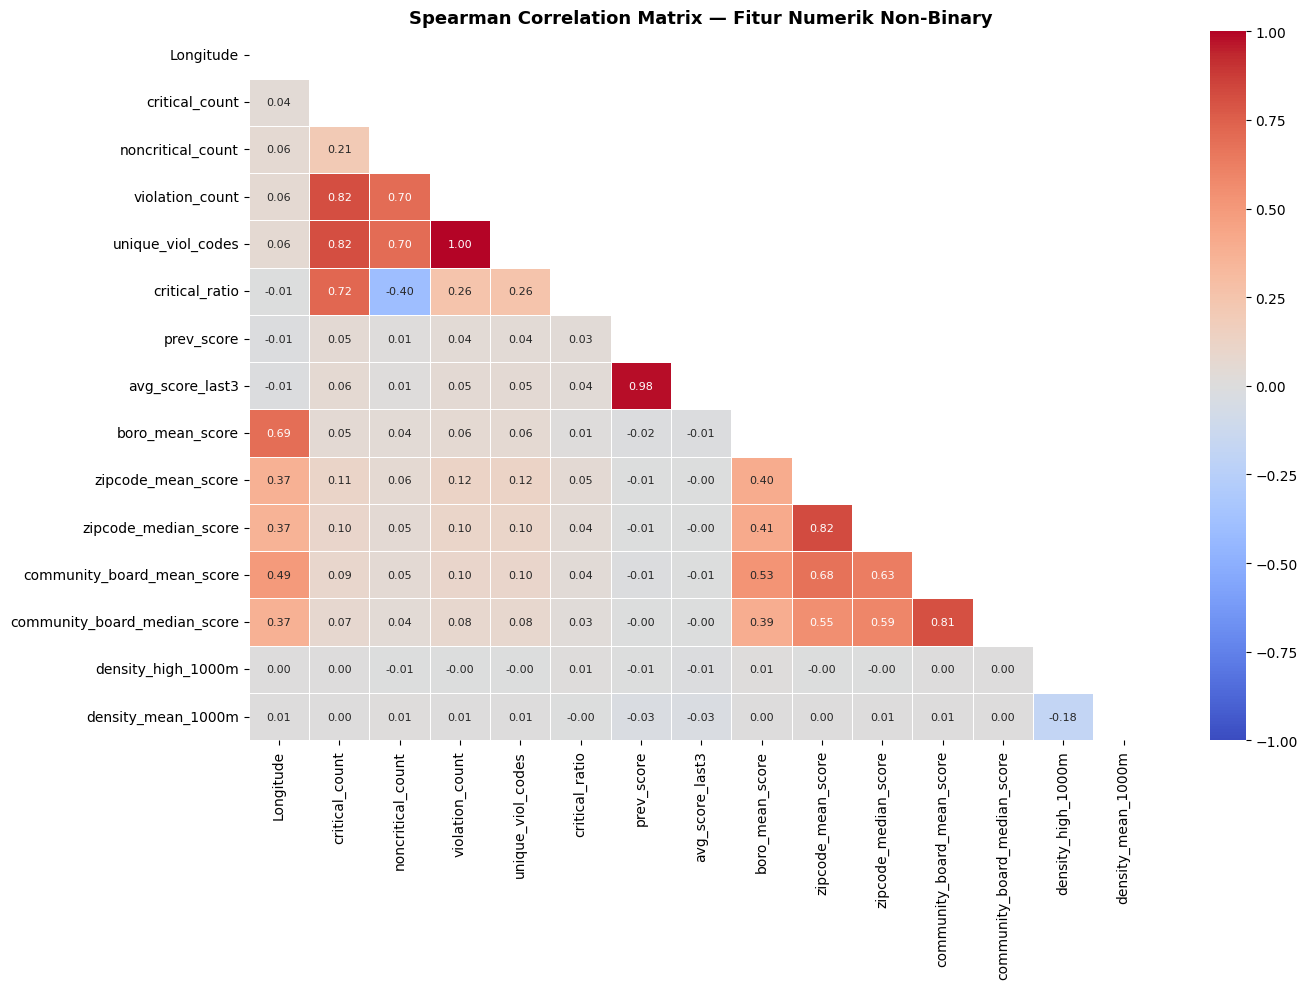

  VIF — Variance Inflation Factor
                     feature        VIF           status
             violation_count        inf   🔴 Tinggi (>10)
           unique_viol_codes        inf   🔴 Tinggi (>10)
             avg_score_last3 234.289531   🔴 Tinggi (>10)
                  prev_score 234.238231   🔴 Tinggi (>10)
              critical_count  12.191489   🔴 Tinggi (>10)
           noncritical_count   8.398632 🟠 Moderat (5-10)
          zipcode_mean_score   6.035654 🟠 Moderat (5-10)
              critical_ratio   5.325820 🟠 Moderat (5-10)
        zipcode_median_score   5.312830 🟠 Moderat (5-10)
  community_board_mean_score   4.764352      ✅ Aman (<5)
community_board_median_score   3.660124      ✅ Aman (<5)
             boro_mean_score   2.229336      ✅ Aman (<5)
                   Longitude   1.856885      ✅ Aman (<5)
          density_mean_1000m   1.019373      ✅ Aman (<5)
          density_high_1000m   1.018845      ✅ Aman (<5)

🔴 Fitur VIF > 10 : 5
🟠 Fitur VIF 5-10 : 4
✅ Fitur VIF

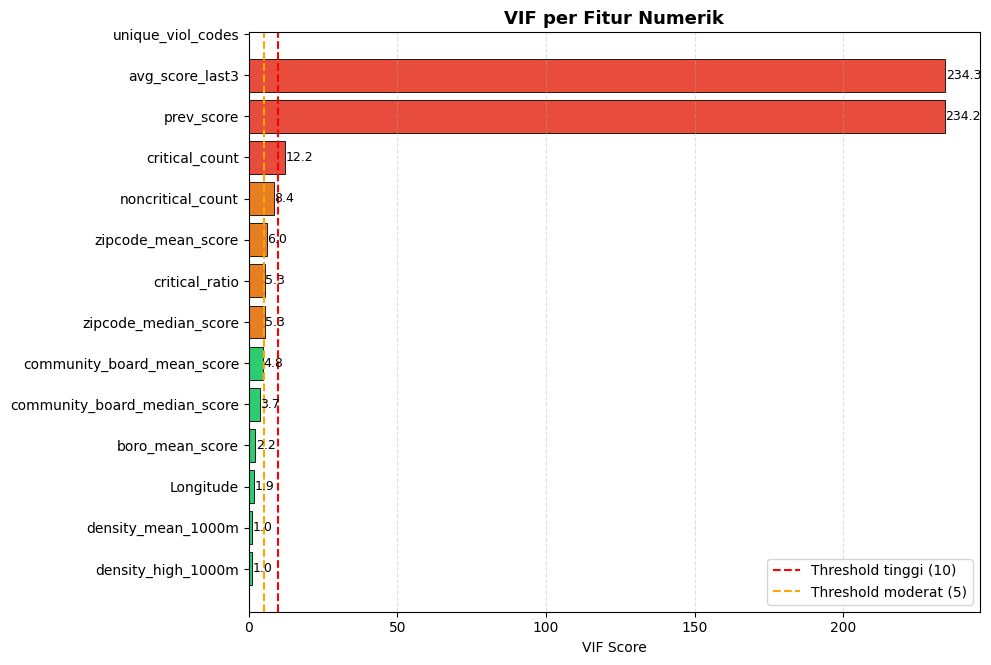

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

num_only = [c for c in X_train.columns
            if not any(c.startswith(p) for p in ["cuisine_", "instype_", "viol_"])
            and c != "has_critical"]

corr_matrix = X_train[num_only].corr(method="spearman")

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={"size": 8}
)
ax.set_title("Spearman Correlation Matrix — Fitur Numerik Non-Binary",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

X_vif = X_train[num_only].copy().dropna()

X_vif_const = add_constant(X_vif)

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif_const.values, i + 1)
            for i in range(len(X_vif.columns))]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_data["status"] = vif_data["VIF"].apply(
    lambda v: "🔴 Tinggi (>10)"   if v > 10
    else      "🟠 Moderat (5-10)" if v > 5
    else      "✅ Aman (<5)"
)

print("=" * 50)
print("  VIF — Variance Inflation Factor")
print("=" * 50)
print(vif_data.to_string(index=False))
print(f"\n🔴 Fitur VIF > 10 : {(vif_data['VIF'] > 10).sum()}")
print(f"🟠 Fitur VIF 5-10 : {((vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)).sum()}")
print(f"✅ Fitur VIF < 5  : {(vif_data['VIF'] <= 5).sum()}")

fig, ax = plt.subplots(figsize=(10, max(5, len(vif_data) * 0.45)))

colors = ["#e74c3c" if v > 10 else "#e67e22" if v > 5 else "#2ecc71"
          for v in vif_data["VIF"]]
bars = ax.barh(vif_data["feature"], vif_data["VIF"],
               color=colors, edgecolor="black", linewidth=0.6)
ax.axvline(10, color="red",    linestyle="--", linewidth=1.5, label="Threshold tinggi (10)")
ax.axvline(5,  color="orange", linestyle="--", linewidth=1.5, label="Threshold moderat (5)")

for bar, val in zip(bars, vif_data["VIF"]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", fontsize=9)

ax.set_title("VIF per Fitur Numerik", fontsize=13, fontweight="bold")
ax.set_xlabel("VIF Score")
ax.legend(); ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
import re

def clean_col_name(col):
    return re.sub(r'[^A-Za-z0-9_]', '_', col)

X_train.columns = [clean_col_name(c) for c in X_train.columns]
X_val.columns   = [clean_col_name(c) for c in X_val.columns]
X_test.columns  = [clean_col_name(c) for c in X_test.columns]

print("✅ Nama kolom dibersihkan — semua model akan pakai nama kolom yang sama")
print(X_train.columns.tolist())

✅ Nama kolom dibersihkan — semua model akan pakai nama kolom yang sama
['Longitude', 'critical_count', 'has_critical', 'noncritical_count', 'violation_count', 'unique_viol_codes', 'critical_ratio', 'viol_02B', 'viol_02G', 'viol_04A', 'viol_04H', 'viol_04L', 'viol_04N', 'viol_05D', 'viol_05F', 'viol_06C', 'viol_06D', 'viol_06F', 'viol_08A', 'viol_10B', 'prev_score', 'avg_score_last3', 'boro_mean_score', 'zipcode_mean_score', 'zipcode_median_score', 'community_board_mean_score', 'community_board_median_score', 'instype_Cycle_Inspection___Initial_Inspection', 'instype_Cycle_Inspection___Re_inspection', 'instype_Cycle_Inspection___Reopening_Inspection', 'instype_Other', 'instype_Pre_permit__Operational____Initial_Inspection', 'instype_Pre_permit__Operational____Re_inspection', 'cuisine_encoded', 'density_high_1000m', 'density_mean_1000m']


# SMOGN — Oversampling untuk Imbalanced Regression ##


## Apa itu SMOGN?

**SMOGN** (Synthetic Minority Over-sampling Technique for Regression with
Gaussian Noise) adalah teknik oversampling khusus untuk regresi dengan
target yang tidak seimbang.

Berbeda dari SMOTE (untuk klasifikasi), SMOGN bekerja pada **target kontinu**:
- Identifikasi rentang target yang **langka** (rare values) — dalam kasus ini SCORE > 30
- Untuk tiap sampel langka, cari tetangga terdekat (KNN)
- Generate sampel sintetis dengan interpolasi antara sampel asli dan tetangganya
- Tambahkan Gaussian Noise kecil untuk variasi

```
Distribusi asli:      [SCORE 0-30: 90%] [SCORE >30: 10%]
Setelah SMOGN:        [SCORE 0-30: 70%] [SCORE >30: 30%]  ← lebih seimbang
```

**Hipotesis:** Dengan lebih banyak contoh SCORE tinggi di training,
model akan lebih baik memprediksi inspeksi berisiko tinggi.

**Yang akan dibandingkan:**
- Baseline LightGBM (tanpa SMOGN)
- LightGBM + SMOGN
- Error per bucket SCORE: apakah bucket > 30 membaik?


In [ ]:
import smogn
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

## Analisis Distribusi SCORE di Training Set ##

In [ ]:

y_train_orig = np.expm1(y_train)

bins   = [0, 5, 10, 15, 20, 30, 40, 75]
labels = ["0-5", "6-10", "11-15", "16-20", "21-30", "31-40", "41-73"]
buckets = pd.cut(y_train_orig, bins=bins, labels=labels,
                 right=True, include_lowest=True)

print("Distribusi SCORE di training set:")
print("=" * 45)
dist = buckets.value_counts().sort_index()
total = len(y_train)
for label in labels:
    n   = dist.get(label, 0)
    pct = n / total * 100
    bar = "#" * int(pct / 2)
    print(f"  {label:<8} {n:>6} ({pct:>5.1f}%) {bar}")
print(f"  {'TOTAL':<8} {total:>6}")

n_high = (y_train_orig > 30).sum()
pct_high = (y_train_orig > 30).mean() * 100
print(f"Rentang bermasalah (SCORE > 30):")
print(f"  Jumlah : {n_high:,} dari {total:,} ({pct_high:.1f}%)")
print("  Ini sangat imbalanced -- model jarang melihat contoh SCORE tinggi")
print("  sehingga tidak belajar pola yang benar untuk rentang ini.")


Distribusi SCORE di training set:
  0-5        5998 ( 12.4%) ######
  6-10       6537 ( 13.6%) ######
  11-15     16964 ( 35.2%) #################
  16-20      3680 (  7.6%) ###
  21-30      7928 ( 16.4%) ########
  31-40      3239 (  6.7%) ###
  41-73      3856 (  8.0%) ###
  TOTAL     48202
Rentang bermasalah (SCORE > 30):
  Jumlah : 7,095 dari 48,202 (14.7%)
  Ini sangat imbalanced -- model jarang melihat contoh SCORE tinggi
  sehingga tidak belajar pola yang benar untuk rentang ini.


## Implementasi SMOGN ##


**Parameter SMOGN yang penting:**

- `rel_thres` — threshold untuk menentukan "rare" value (0-1). Nilai lebih rendah = lebih banyak nilai dianggap langka
- `rel_method` — cara mendefinisikan relevansi: `"auto"` (otomatis) atau `"manual"` (manual threshold)
- `k` — jumlah tetangga KNN untuk interpolasi
- `samp_method` — strategi sampling: `"balance"` atau `"extreme"`

Kita akan coba dua konfigurasi:
- **SMOGN Conservative:** `rel_thres=0.8`, oversampling moderat
- **SMOGN Aggressive:** `rel_thres=0.6`, oversampling lebih agresif


In [ ]:

df_smogn_input = X_train.copy()
df_smogn_input["SCORE"] = y_train.values

print(f"Shape sebelum SMOGN: {df_smogn_input.shape}")
print(f"% SCORE > log1p(30): {(y_train > np.log1p(30)).mean()*100:.1f}%")
print(f"Range SCORE (log1p): [{y_train.min():.3f}, {y_train.max():.3f}]")
print()

df_smogn_input = df_smogn_input.replace([np.inf, -np.inf], np.nan)
for col in df_smogn_input.columns:
    if df_smogn_input[col].isna().any():
        df_smogn_input[col] = df_smogn_input[col].fillna(df_smogn_input[col].median())

print("Input data bersih, siap untuk SMOGN")


Shape sebelum SMOGN: (48202, 37)
% SCORE > log1p(30): 14.7%
Range SCORE (log1p): [0.000, 4.304]

Input data bersih, siap untuk SMOGN


In [ ]:

print("Running SMOGN (Conservative)...")
print("Ini mungkin memakan waktu 2-5 menit...")

try:
    df_test = smogn.smoter(
        data        = df_smogn_input,
        y           = "SCORE",
        k           = 5,
        samp_method = "balance",
        rel_thres   = 0.8,
        rel_method  = "auto",
        under_samp  = True,
    )
    
    X_train_smogn_c = df_test.drop(columns=["SCORE"])
    y_train_smogn_c = df_test["SCORE"]
    
    print(f"Shape setelah SMOGN Conservative: {df_test.shape}")
    print(f"  Training samples: {len(y_train_smogn_c):,} (asli: {len(y_train):,})")
    
    y_orig_c = np.expm1(y_train_smogn_c)
    buckets_c = pd.cut(y_orig_c, bins=bins, labels=labels,
                       right=True, include_lowest=True)
    dist_c = buckets_c.value_counts().sort_index()
    print(f"  % SCORE > 30 setelah SMOGN: {(y_orig_c > 30).mean()*100:.1f}%")
    smogn_conservative_ok = True
    print("SMOGN Conservative berhasil!")
    
except Exception as e:
    print(f"Error: {e}")
    smogn_conservative_ok = False
    print("SMOGN Conservative gagal, skip.")


Running SMOGN (Conservative)...
Ini mungkin memakan waktu 2-5 menit...


r_index: 100%|##########| 427/427 [00:00<00:00, 957.22it/s]


Shape setelah SMOGN Conservative: (44820, 37)
  Training samples: 44,820 (asli: 48,202)
  % SCORE > 30 setelah SMOGN: 7.3%
SMOGN Conservative berhasil!


In [ ]:

# print("Running SMOGN (Aggressive)...")
# print("Ini mungkin memakan waktu 2-5 menit...")

# try:
#     df_smogn_aggressive = smogn.smoter(
#         data     = df_smogn_input,
#         y        = "SCORE",
#         k        = 7,             
#         samp_method = "extreme",  
#         rel_thres   = 0.6,       
#         rel_method  = "auto",
#         under_samp  = True,
#         seed     = 42
#     )
    
#     X_train_smogn_a = df_smogn_aggressive.drop(columns=["SCORE"])
#     y_train_smogn_a = df_smogn_aggressive["SCORE"]
    
#     print(f"Shape setelah SMOGN Aggressive: {df_smogn_aggressive.shape}")
#     print(f"  Training samples: {len(y_train_smogn_a):,} (asli: {len(y_train):,})")
    
#     y_orig_a = np.expm1(y_train_smogn_a)
#     print(f"  % SCORE > 30 setelah SMOGN: {(y_orig_a > 30).mean()*100:.1f}%")
#     smogn_aggressive_ok = True
#     print("SMOGN Aggressive berhasil!")
    
# except Exception as e:
#     print(f"Error: {e}")
#     smogn_aggressive_ok = False
#     print("SMOGN Aggressive gagal, skip.")


Running SMOGN (Aggressive)...
Ini mungkin memakan waktu 2-5 menit...
Error: name 'smogn' is not defined
SMOGN Aggressive gagal, skip.


## Visualisasi Distribusi Sebelum vs Sesudah SMOGN ##

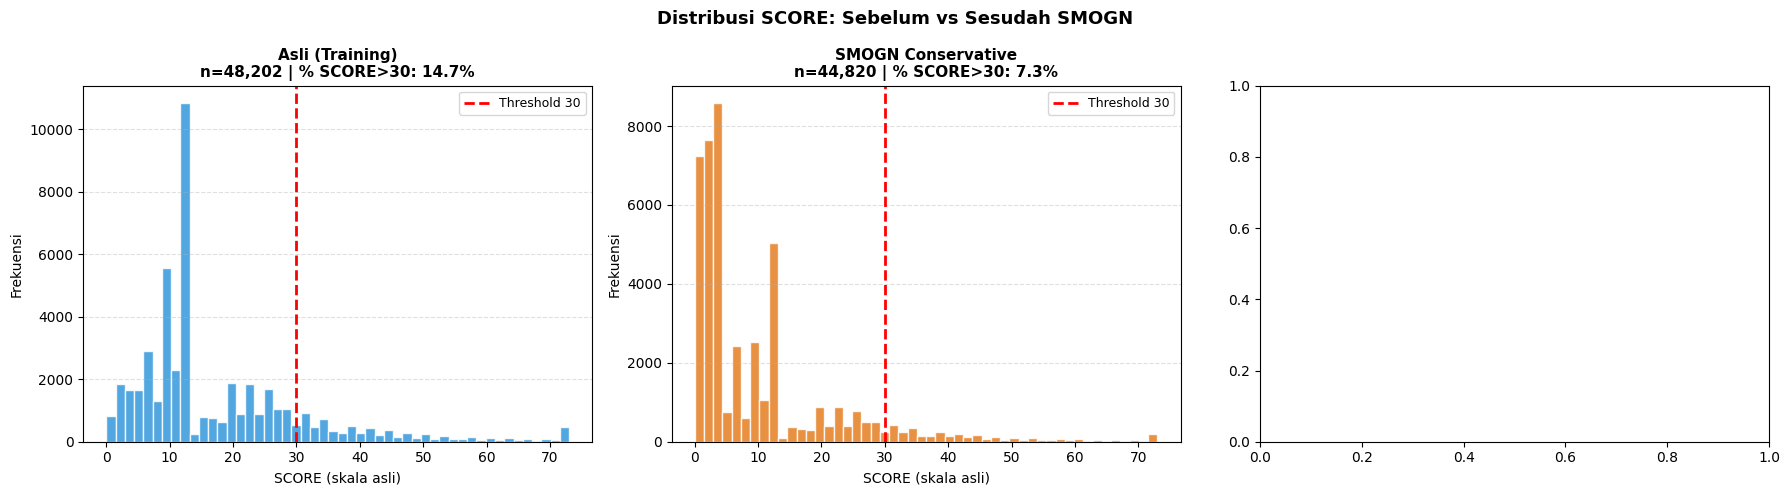

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [("Asli (Training)", y_train, "#3498db")]
if smogn_conservative_ok:
    datasets.append(("SMOGN Conservative", y_train_smogn_c, "#e67e22"))

for ax, (label, y_data, color) in zip(axes, datasets):
    y_orig = np.expm1(y_data)
    ax.hist(y_orig, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(30, color="red", linestyle="--", linewidth=2,
               label="Threshold 30")
    pct_high = (y_orig > 30).mean() * 100
    ax.set_title(f"{label}\nn={len(y_data):,} | % SCORE>30: {pct_high:.1f}%",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("SCORE (skala asli)")
    ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Distribusi SCORE: Sebelum vs Sesudah SMOGN",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Training Model: Baseline vs SMOGN ##

In [ ]:

def evaluate_by_bucket(y_true, y_pred, model_name):
    bins   = [0, 5, 10, 15, 20, 30, 40, 75]
    labels = ["0-5", "6-10", "11-15", "16-20", "21-30", "31-40", "41-73"]
    
    y_true_orig = np.expm1(np.clip(np.array(y_true), 0, 6))
    y_pred_orig = np.expm1(np.clip(y_pred, 0, 6))
    
    buckets = pd.cut(y_true_orig, bins=bins, labels=labels,
                     right=True, include_lowest=True)
    
    results = {}
    for label in labels:
        mask = buckets == label
        if mask.sum() == 0:
            continue
        results[label] = {
            "n":   mask.sum(),
            "mae": mean_absolute_error(y_true_orig[mask], y_pred_orig[mask])
        }
    
    overall_mae  = mean_absolute_error(y_true_orig, y_pred_orig)
    overall_r2   = r2_score(y_true, y_pred)
    overall_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Overall MAE  : {overall_mae:.4f} poin SCORE asli")
    print(f"  Overall R²   : {overall_r2:.4f}")
    print(f"  Overall RMSE : {overall_rmse:.4f} (log scale)")
    print(f"\n  MAE per bucket SCORE:")
    print(f"  {'Bucket':<10} {'n':>6} {'MAE':>8}")
    print(f"  {'-'*26}")
    for label in labels:
        if label not in results:
            continue
        r    = results[label]
        flag = " <-- HIGH SCORE" if label in ["31-40", "41-73"] else ""
        print(f"  {label:<10} {r['n']:>6} {r['mae']:>8.3f}{flag}")
    
    return {
        "model": model_name,
        "overall_mae": overall_mae,
        "overall_r2":  overall_r2,
        "overall_rmse": overall_rmse,
        "buckets": results
    }

LGB_PARAMS = dict(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    max_depth=7, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, min_child_samples=20,
    random_state=42, n_jobs=-1, verbose=-1
)

comparison_results = []

print("Training Baseline LightGBM...")
lgb_base = lgb.LGBMRegressor(**LGB_PARAMS)
lgb_base.fit(X_train, y_train,
             eval_set=[(X_val, y_val)],
             callbacks=[lgb.early_stopping(30, verbose=False),
                        lgb.log_evaluation(-1)])
y_pred_base = lgb_base.predict(X_val)
res_base = evaluate_by_bucket(y_val.values, y_pred_base, "Baseline (tanpa SMOGN)")
comparison_results.append(res_base)


Training Baseline LightGBM...

  Baseline (tanpa SMOGN)
  Overall MAE  : 3.0615 poin SCORE asli
  Overall R²   : 0.8592
  Overall RMSE : 0.3296 (log scale)

  MAE per bucket SCORE:
  Bucket          n      MAE
  --------------------------
  0-5          1331    1.573
  6-10         1236    1.367
  11-15        3512    1.125
  16-20         697    2.454
  21-30        1738    2.893
  31-40         748    4.941 <-- HIGH SCORE
  41-73        1067   12.609 <-- HIGH SCORE


In [ ]:

if smogn_conservative_ok:
    print("Training LightGBM + SMOGN Conservative...")
    lgb_smogn_c = lgb.LGBMRegressor(**LGB_PARAMS)
    lgb_smogn_c.fit(X_train_smogn_c, y_train_smogn_c,
                    eval_set=[(X_val, y_val)],
                    callbacks=[lgb.early_stopping(30, verbose=False),
                               lgb.log_evaluation(-1)])
    y_pred_sc = lgb_smogn_c.predict(X_val)
    res_sc = evaluate_by_bucket(y_val.values, y_pred_sc, "LightGBM + SMOGN Conservative")
    comparison_results.append(res_sc)
else:
    print("SMOGN Conservative tidak tersedia, skip.")


Training LightGBM + SMOGN Conservative...

  LightGBM + SMOGN Conservative
  Overall MAE  : 3.1933 poin SCORE asli
  Overall R²   : 0.8461
  Overall RMSE : 0.3446 (log scale)

  MAE per bucket SCORE:
  Bucket          n      MAE
  --------------------------
  0-5          1331    1.183
  6-10         1236    1.298
  11-15        3512    1.220
  16-20         697    2.698
  21-30        1738    3.167
  31-40         748    5.285 <-- HIGH SCORE
  41-73        1067   13.292 <-- HIGH SCORE


## Perbandingan Baseline vs SMOGN ##

In [ ]:

labels_ordered = ["0-5", "6-10", "11-15", "16-20", "21-30", "31-40", "41-73"]
baseline_mae   = comparison_results[0]["overall_mae"]

print("=" * 75)
print("  PERBANDINGAN BASELINE vs SMOGN — MAE per Bucket SCORE")
print("=" * 75)

header = f"{'Bucket':<10}"
for res in comparison_results:
    short = res["model"][:18]
    header += f" {short:>18}"
print(header)
print("-" * 75)

for label in labels_ordered:
    row = f"{label:<10}"
    for res in comparison_results:
        mae = res["buckets"].get(label, {}).get("mae", float("nan"))
        row += f" {mae:>18.3f}"
    flag = " <-- HIGH" if label in ["31-40", "41-73"] else ""
    print(row + flag)

print("-" * 75)
row_overall = f"{'Overall':<10}"
for res in comparison_results:
    row_overall += f" {res['overall_mae']:>18.4f}"
print(row_overall)

row_r2 = f"{'Val R²':<10}"
for res in comparison_results:
    row_r2 += f" {res['overall_r2']:>18.4f}"
print(row_r2)

print("=" * 75)
print()

if len(comparison_results) > 1:
    for res in comparison_results[1:]:
        delta_overall = res["overall_mae"] - baseline_mae
        
        high_base = (comparison_results[0]["buckets"].get("31-40", {}).get("mae", 0) +
                     comparison_results[0]["buckets"].get("41-73", {}).get("mae", 0)) / 2
        high_smogn = (res["buckets"].get("31-40", {}).get("mae", 0) +
                      res["buckets"].get("41-73", {}).get("mae", 0)) / 2
        delta_high = high_smogn - high_base
        
        print(f"{res['model']}:")
        print(f"  Delta Overall MAE : {delta_overall:+.4f} "
              f"({'lebih baik' if delta_overall < 0 else 'lebih buruk'})")
        print(f"  Delta MAE >30     : {delta_high:+.3f} "
              f"({'lebih baik' if delta_high < 0 else 'lebih buruk'})")
        
        if delta_overall < -0.05:
            verdict = "SANGAT DIREKOMENDASIKAN"
        elif delta_overall < 0 and delta_high < 0:
            verdict = "DIREKOMENDASIKAN (balance)"
        elif delta_high < -2 and delta_overall < 0.1:
            verdict = "WORTH dicoba (high score jauh lebih baik)"
        elif delta_overall > 0.1:
            verdict = "TIDAK DIREKOMENDASIKAN (overall memburuk)"
        else:
            verdict = "NETRAL (perubahan kecil)"
        print(f"  Verdict: {verdict}")
        print()


  PERBANDINGAN BASELINE vs SMOGN — MAE per Bucket SCORE
Bucket     Baseline (tanpa SM LightGBM + SMOGN C
---------------------------------------------------------------------------
0-5                     1.573              1.183
6-10                    1.367              1.298
11-15                   1.125              1.220
16-20                   2.454              2.698
21-30                   2.893              3.167
31-40                   4.941              5.285 <-- HIGH
41-73                  12.609             13.292 <-- HIGH
---------------------------------------------------------------------------
Overall                3.0615             3.1933
Val R²                 0.8592             0.8461

LightGBM + SMOGN Conservative:
  Delta Overall MAE : +0.1318 (lebih buruk)
  Delta MAE >30     : +0.513 (lebih buruk)
  Verdict: TIDAK DIREKOMENDASIKAN (overall memburuk)



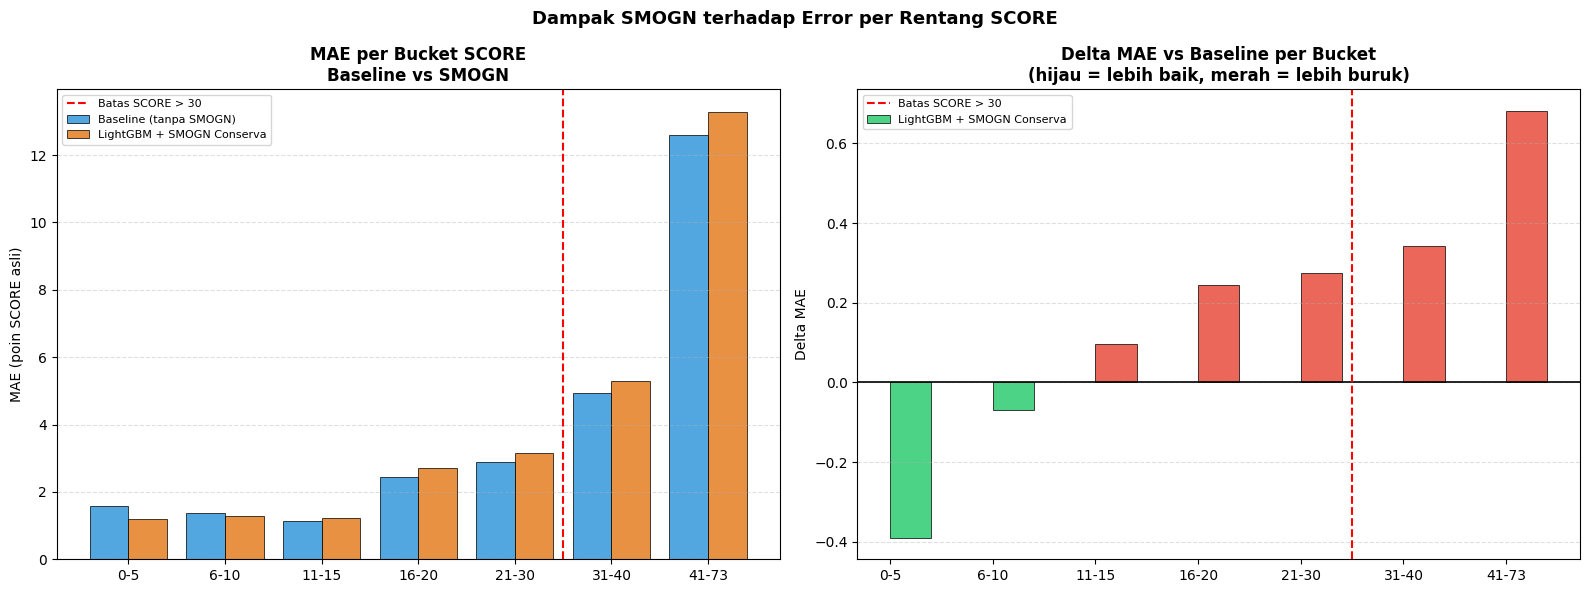

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bucket_labels = ["0-5", "6-10", "11-15", "16-20", "21-30", "31-40", "41-73"]
x = np.arange(len(bucket_labels))
width = 0.8 / len(comparison_results)
colors = ["#3498db", "#e67e22", "#e74c3c", "#2ecc71"]

for j, res in enumerate(comparison_results):
    maes   = [res["buckets"].get(b, {}).get("mae", 0) for b in bucket_labels]
    offset = (j - len(comparison_results)/2 + 0.5) * width
    axes[0].bar(x + offset, maes, width, label=res["model"][:25],
                color=colors[j % len(colors)], edgecolor="black",
                linewidth=0.6, alpha=0.85)

axes[0].axvline(4.5, color="red", linestyle="--", linewidth=1.5,
                label="Batas SCORE > 30")
axes[0].set_xticks(x)
axes[0].set_xticklabels(bucket_labels)
axes[0].set_title("MAE per Bucket SCORE\nBaseline vs SMOGN",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("MAE (poin SCORE asli)")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Delta dari baseline
if len(comparison_results) > 1:
    base_maes = [comparison_results[0]["buckets"].get(b, {}).get("mae", 0)
                 for b in bucket_labels]
    for j, res in enumerate(comparison_results[1:], 1):
        maes   = [res["buckets"].get(b, {}).get("mae", 0) for b in bucket_labels]
        deltas = [m - b for m, b in zip(maes, base_maes)]
        offset = (j - len(comparison_results)/2 + 0.5) * width
        bar_colors = ["#2ecc71" if d < 0 else "#e74c3c" for d in deltas]
        axes[1].bar(x + offset, deltas, width, label=res["model"][:25],
                    color=bar_colors, edgecolor="black", linewidth=0.6, alpha=0.85)

axes[1].axhline(0, color="black", linewidth=1.2)
axes[1].axvline(4.5, color="red", linestyle="--", linewidth=1.5,
                label="Batas SCORE > 30")
axes[1].set_xticks(x)
axes[1].set_xticklabels(bucket_labels)
axes[1].set_title("Delta MAE vs Baseline per Bucket\n(hijau = lebih baik, merah = lebih buruk)",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Delta MAE")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Dampak SMOGN terhadap Error per Rentang SCORE",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


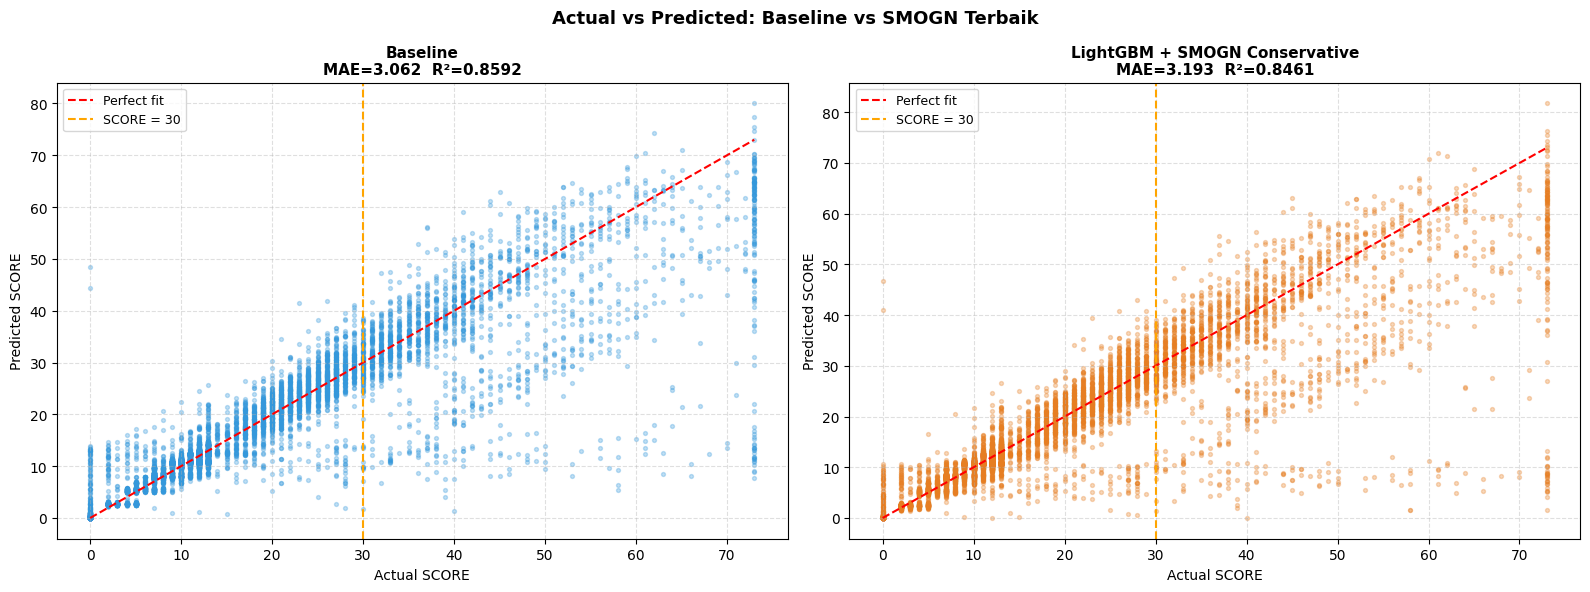

In [ ]:

best_smogn = None
if len(comparison_results) > 1:
    best_smogn = min(comparison_results[1:], key=lambda x: x["overall_mae"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

y_val_orig = np.expm1(y_val.values)

y_pred_orig_base = np.expm1(np.clip(y_pred_base, 0, 6))
axes[0].scatter(y_val_orig, y_pred_orig_base, alpha=0.3, s=8, color="#3498db")
mx = y_val_orig.max()
axes[0].plot([0, mx], [0, mx], "r--", linewidth=1.5, label="Perfect fit")
axes[0].axvline(30, color="orange", linestyle="--", linewidth=1.5,
                label="SCORE = 30")
axes[0].set_title(f"Baseline\nMAE={comparison_results[0]['overall_mae']:.3f}  "
                  f"R²={comparison_results[0]['overall_r2']:.4f}",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Actual SCORE"); axes[0].set_ylabel("Predicted SCORE")
axes[0].legend(fontsize=9); axes[0].grid(linestyle="--", alpha=0.4)

if best_smogn:
    if "Conservative" in best_smogn["model"]:
        y_pred_smogn_best = y_pred_sc
    else:
        y_pred_smogn_best = y_pred_sa
    
    y_pred_orig_smogn = np.expm1(np.clip(y_pred_smogn_best, 0, 6))
    axes[1].scatter(y_val_orig, y_pred_orig_smogn, alpha=0.3, s=8, color="#e67e22")
    axes[1].plot([0, mx], [0, mx], "r--", linewidth=1.5, label="Perfect fit")
    axes[1].axvline(30, color="orange", linestyle="--", linewidth=1.5,
                    label="SCORE = 30")
    axes[1].set_title(f"{best_smogn['model']}\n"
                      f"MAE={best_smogn['overall_mae']:.3f}  "
                      f"R²={best_smogn['overall_r2']:.4f}",
                      fontsize=11, fontweight="bold")
    axes[1].set_xlabel("Actual SCORE"); axes[1].set_ylabel("Predicted SCORE")
    axes[1].legend(fontsize=9); axes[1].grid(linestyle="--", alpha=0.4)
else:
    axes[1].text(0.5, 0.5, "SMOGN tidak berhasil", ha="center", va="center",
                 transform=axes[1].transAxes, fontsize=14)

plt.suptitle("Actual vs Predicted: Baseline vs SMOGN Terbaik",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
